# Multimodal Disjoint Paired Attack (Variant A): Aggregation, Analysis & Figures

## Disclaimer: This notebook was constructed with assistance from Gemini 3.1 Pro for code completion, debugging, and graph styling.

## Setup

In [1]:
import os, json, warnings, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

BASELINE_CSV       = 'evaluation/baseline_iou_all.csv'
VISUAL_CSV         = 'evaluation/visual/unimodal_visual_flat.csv'
TEXTUAL_CSV        = 'evaluation/textual/unimodal_textual_flat.csv'
VARIANT_A_BASE_DIR = 'multimodal/variant_a'
OUTPUT_DIR         = 'evaluation/variant_a'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SCENE_TYPE_MAP = {
    'single/solo':  'Isolated',
    'single/multi': 'Clustered',
    'multi':        'Mixed',
}
SCENE_ORDER = ['Isolated', 'Clustered', 'Mixed']

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

## Constants & Mappings

In [2]:
IMAGE_ATTACKS = [
    'jpeg_filter', 'pixelate', 'defocus_blur',
    'motion_blur', 'gaussian_noise', 'fog_filter',
]
TEXT_ATTACKS = [
    'homophone', 'synonym', 'fragmentation',
    'character_noise', 'ata_saliency',
]

IMG_NICE = {
    'jpeg_filter': 'JPEG Compression', 'pixelate': 'Pixelation',
    'defocus_blur': 'Defocus Blur', 'motion_blur': 'Motion Blur',
    'gaussian_noise': 'Gaussian Noise', 'fog_filter': 'Fog Overlay',
}
TXT_NICE = {
    'homophone': 'Homophone', 'synonym': 'Synonym',
    'fragmentation': 'Fragmentation', 'character_noise': 'Character Noise',
    'ata_saliency': 'Lexical Saliency',
}

IMG_CATEGORY_MAP = {
    'jpeg_filter': 'Digital', 'pixelate': 'Digital',
    'defocus_blur': 'Blur', 'motion_blur': 'Blur',
    'gaussian_noise': 'Noise', 'fog_filter': 'Weather',
}
TXT_CATEGORY_MAP = {
    'homophone': 'Semantic', 'synonym': 'Semantic',
    'fragmentation': 'Orthographic', 'character_noise': 'Orthographic',
    'ata_saliency': 'Orthographic',
}

SCENE_COLORS = {'Isolated': '#4878A8', 'Clustered': '#E8913A', 'Mixed': '#59A668'}

POP_SIZE = 30
NUM_GENERATIONS = 15
BATCH_SIZE = 15
EARLY_STOP_IOU_MAX = 0.35
EARLY_STOP_IMG_DIST_MAX = 0.10
EARLY_STOP_TXT_SIM_MIN = 0.70

N_PAIRINGS = len(IMAGE_ATTACKS) * len(TEXT_ATTACKS)
print(f'Image attacks: {len(IMAGE_ATTACKS)}, Text attacks: {len(TEXT_ATTACKS)}')
print(f'Total pairings: {N_PAIRINGS}')

Image attacks: 6, Text attacks: 5
Total pairings: 30


## Load Variant A Results

In [3]:
def get_scene_type(category_str):
    """Map folder category to scene type label."""
    mapping = {
        'single/solo':  'Isolated',
        'single_solo':  'Isolated',
        'single/multi': 'Clustered',
        'single_multi': 'Clustered',
        'multi':        'Mixed',
    }
    cat = category_str.replace('\\', '/').strip('/')
    return mapping.get(cat, 'Unknown')


sample_records = []   # one row per sample (front-level summary)
solution_records = [] # one row per Pareto-front solution
errors = []

for rel_dir, scene_label in SCENE_TYPE_MAP.items():
    group_dir = os.path.join(VARIANT_A_BASE_DIR, rel_dir)
    if not os.path.isdir(group_dir):
        errors.append(f'MISSING DIR: {group_dir}')
        continue

    folder_ids = sorted(
        [d for d in os.listdir(group_dir) if os.path.isdir(os.path.join(group_dir, d))],
        key=lambda x: int(x)
    )

    for fid in folder_ids:
        pf_path = os.path.join(group_dir, fid, 'pareto_front.json')
        if not os.path.isfile(pf_path):
            errors.append(f'MISSING: {pf_path}')
            continue

        with open(pf_path) as f:
            pf = json.load(f)
            
        sample_rec = {
            'scene_type':        scene_label,
            'sample_id':         int(fid),
            'folder_path':       pf['data_source']['folder_path'],
            'filename':          pf['data_source']['filename'],
            'baseline_iou':      pf['baseline_iou'],
            'swad_star':         pf['swad_star'],
            'swad_star_index':   pf['swad_star_index'],
            'early_stopped':     pf['early_stopped'],
            'early_stop_gen':    pf.get('early_stop_generation'),
            'total_evaluations': pf['total_evaluations'],
            'skipped_evals':     pf['skipped_evaluations'],
            'n_solutions':       pf['n_solutions'],
            'n_gt_objects':      len(pf['ground_truth_bboxes']),
        }

        swad_idx = pf['swad_star_index']
        swad_sol = pf['solutions'][swad_idx]
        sample_rec['swad_img_attack']  = swad_sol['genome']['img_attack']
        sample_rec['swad_img_scale']   = swad_sol['genome']['img_scale']
        sample_rec['swad_txt_attack']  = swad_sol['genome']['txt_attack']
        sample_rec['swad_txt_scale']   = swad_sol['genome']['txt_scale']
        sample_rec['swad_iou_m']       = swad_sol['objectives']['iou']
        sample_rec['swad_img_dist']    = swad_sol['objectives']['img_dist']
        sample_rec['swad_txt_sim']     = swad_sol['objectives']['txt_sim']
        sample_rec['swad_txt_dist']    = swad_sol['objectives']['txt_dist']
        sample_rec['swad_delta_m']     = swad_sol['swad_metrics']['delta_m_plus']
        sample_rec['swad_phi']         = swad_sol['swad_metrics']['phi']
        sample_rec['swad_token_count'] = swad_sol['vlm_output']['token_count']
        sample_rec['swad_raw_tokens']  = swad_sol['vlm_output']['raw_token_count']
        sample_rec['swad_runtime']     = swad_sol['vlm_output']['runtime_seconds']
        sample_rec['swad_l2_distance'] = swad_sol['l2_distance']
        
        l2_dists = [sol['l2_distance'] for sol in pf['solutions']]
        l2_idx = int(np.argmin(l2_dists))
        l2_sol = pf['solutions'][l2_idx]
        sample_rec['l2_index']       = l2_idx
        sample_rec['l2_img_attack']  = l2_sol['genome']['img_attack']
        sample_rec['l2_img_scale']   = l2_sol['genome']['img_scale']
        sample_rec['l2_txt_attack']  = l2_sol['genome']['txt_attack']
        sample_rec['l2_txt_scale']   = l2_sol['genome']['txt_scale']
        sample_rec['l2_iou_m']       = l2_sol['objectives']['iou']
        sample_rec['l2_img_dist']    = l2_sol['objectives']['img_dist']
        sample_rec['l2_txt_sim']     = l2_sol['objectives']['txt_sim']
        sample_rec['l2_txt_dist']    = l2_sol['objectives']['txt_dist']
        sample_rec['l2_l2_distance'] = l2_sol['l2_distance']
        sample_rec['l2_swad']        = l2_sol['swad_metrics']['swad']

        sample_records.append(sample_rec)

        for sol in pf['solutions']:
            sol_rec = {
                'scene_type':   scene_label,
                'sample_id':    int(fid),
                'baseline_iou': pf['baseline_iou'],
                'sol_index':    sol['index'],
                'img_attack':   sol['genome']['img_attack'],
                'img_scale':    sol['genome']['img_scale'],
                'txt_attack':   sol['genome']['txt_attack'],
                'txt_scale':    sol['genome']['txt_scale'],
                'iou':          sol['objectives']['iou'],
                'img_dist':     sol['objectives']['img_dist'],
                'txt_dist':     sol['objectives']['txt_dist'],
                'txt_sim':      sol['objectives']['txt_sim'],
                'delta_m_plus': sol['swad_metrics']['delta_m_plus'],
                'phi':          sol['swad_metrics']['phi'],
                'swad':         sol['swad_metrics']['swad'],
                'l2_distance':  sol['l2_distance'],
                'token_count':  sol['vlm_output']['token_count'],
                'raw_token_count': sol['vlm_output']['raw_token_count'],
                'runtime_seconds': sol['vlm_output']['runtime_seconds'],
            }
            sol_rec['pairing'] = f"{sol['genome']['img_attack']}+{sol['genome']['txt_attack']}"
            solution_records.append(sol_rec)

if errors:
    print(f'{len(errors)} errors during loading:')
    for e in errors[:10]:
        print(f'   {e}')

df_samples = pd.DataFrame(sample_records)
df_sols = pd.DataFrame(solution_records)

print(f'Loaded {len(df_samples)} samples with {len(df_sols)} total Pareto front solutions')
print(f'Samples per scene type:')
print(df_samples.groupby('scene_type').size().reindex(SCENE_ORDER))

Loaded 750 samples with 13354 total Pareto front solutions
Samples per scene type:
scene_type
Isolated     250
Clustered    250
Mixed        250
dtype: int64


In [4]:
df_samples.to_csv(os.path.join(OUTPUT_DIR, 'variant_a_samples.csv'), index=False)
df_sols.to_csv(os.path.join(OUTPUT_DIR, 'variant_a_solutions.csv'), index=False)
print('Saved flat CSVs')

Saved flat CSVs


## Data Integrity Checks

In [5]:
assert len(df_samples) == 750, f'Expected 750 samples, got {len(df_samples)}'
assert all(
    df_samples.groupby('scene_type').size().reindex(SCENE_ORDER) == 250
), 'Group sizes != 250'

assert (df_samples['baseline_iou'] > 0.5).all(), \
    f'{(df_samples["baseline_iou"] <= 0.5).sum()} samples have baseline_iou <= 0.5'

assert df_samples['swad_star'].between(0, 1).all(), 'SWAD* out of range'

assert df_samples['swad_img_attack'].isin(IMAGE_ATTACKS).all(), 'Invalid image attack'
assert df_samples['swad_txt_attack'].isin(TEXT_ATTACKS).all(), 'Invalid text attack'

print('All integrity checks passed')
print(f'Total Pareto front solutions: {len(df_sols):,}')
print(f'Mean front size: {df_samples.n_solutions.mean():.1f} '
      f'(median={df_samples.n_solutions.median():.0f}, '
      f'range=[{df_samples.n_solutions.min()}, {df_samples.n_solutions.max()}])')

All integrity checks passed
Total Pareto front solutions: 13,354
Mean front size: 17.8 (median=16, range=[1, 30])


## Pareto Front Analysis

In [6]:
print('=== Pareto Front Size Statistics ===')
print(f'{"Scene Type":<18} {"Mean":>6} {"Med":>5} {"Std":>6} {"Min":>4} {"Max":>4}')
print('-' * 48)
for st in SCENE_ORDER:
    sub = df_samples[df_samples.scene_type == st]['n_solutions']
    print(f'{st:<18} {sub.mean():>6.1f} {sub.median():>5.0f} '
          f'{sub.std():>6.1f} {sub.min():>4} {sub.max():>4}')
ovr = df_samples['n_solutions']
print('-' * 48)
print(f'{"Overall":<18} {ovr.mean():>6.1f} {ovr.median():>5.0f} '
      f'{ovr.std():>6.1f} {ovr.min():>4} {ovr.max():>4}')

=== Pareto Front Size Statistics ===
Scene Type           Mean   Med    Std  Min  Max
------------------------------------------------
Isolated             22.3    30    9.7    1   30
Clustered            18.6    18   10.4    1   30
Mixed                12.5    10    7.3    1   30
------------------------------------------------
Overall              17.8    16   10.0    1   30


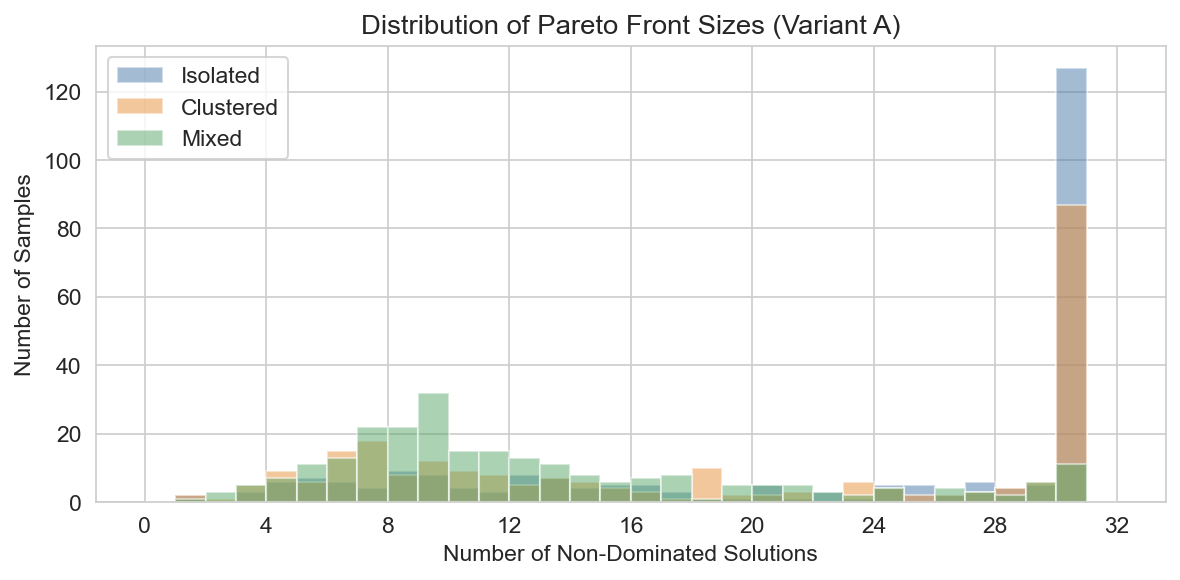

In [7]:
# ============================================================
# FIGURE 1: Histogram of Pareto front sizes across all 750 samples
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))

for st in SCENE_ORDER:
    vals = df_samples[df_samples.scene_type == st]['n_solutions']
    ax.hist(vals, bins=range(0, int(vals.max()) + 3), alpha=0.5,
            label=st, color=SCENE_COLORS[st], edgecolor='white')

ax.set_xlabel('Number of Non-Dominated Solutions')
ax.set_ylabel('Number of Samples')
ax.set_title('Distribution of Pareto Front Sizes (Variant A)')
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_pareto_front_sizes.pdf'))
plt.show()

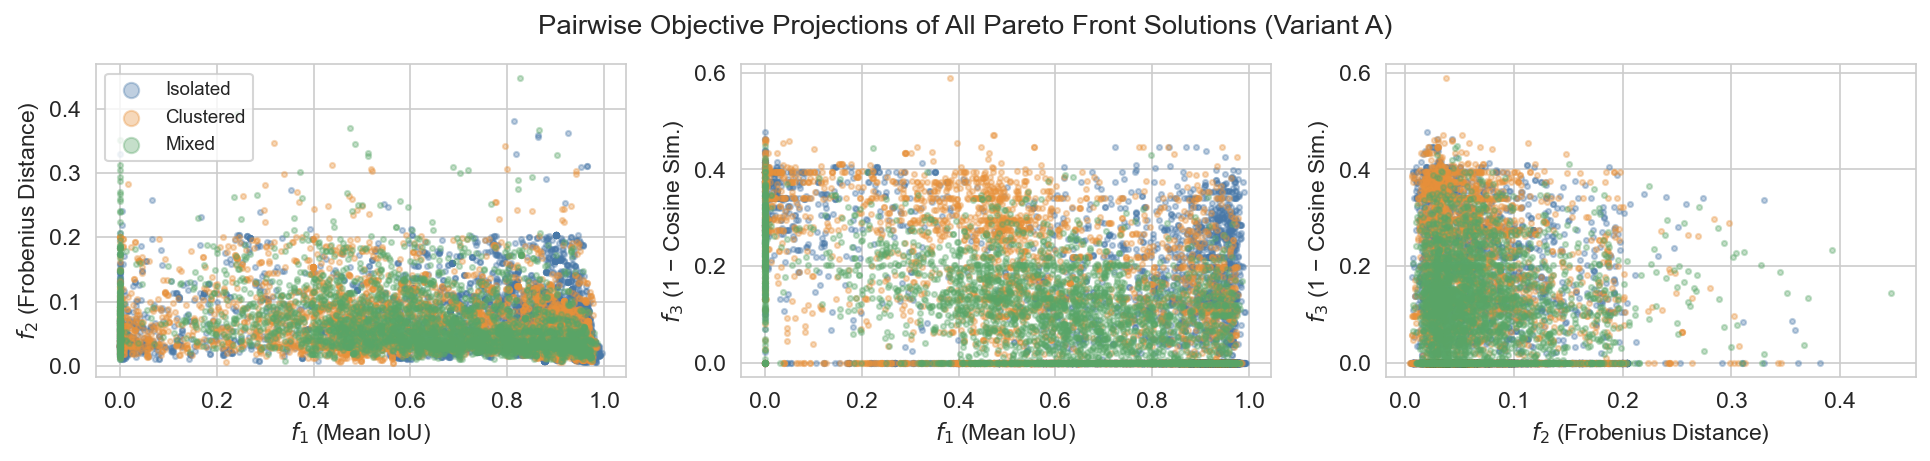

In [8]:
# ============================================================
# FIGURE 2: 2D scatter projections of ALL Pareto front solutions
#           Three panels: f1 vs f2, f1 vs f3, f2 vs f3
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

pairs = [
    ('iou', 'img_dist', '$f_1$ (Mean IoU)', '$f_2$ (Frobenius Distance)'),
    ('iou', 'txt_dist', '$f_1$ (Mean IoU)', '$f_3$ (1 − Cosine Sim.)'),
    ('img_dist', 'txt_dist', '$f_2$ (Frobenius Distance)', '$f_3$ (1 − Cosine Sim.)'),
]

for ax, (xc, yc, xl, yl) in zip(axes, pairs):
    for st in SCENE_ORDER:
        sub = df_sols[df_sols.scene_type == st]
        ax.scatter(sub[xc], sub[yc], s=6, alpha=0.35,
                   color=SCENE_COLORS[st], label=st)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)

axes[0].legend(markerscale=3, fontsize=9)
fig.suptitle('Pairwise Objective Projections of All Pareto Front Solutions (Variant A)', y=0.95)
plt.tight_layout(w_pad=1.5)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_pareto_2d_projections.pdf'))
plt.show()

In [9]:
print('=== Objective Ranges Across All Pareto Solutions ===')
for col, label in [('iou', 'f1: IoU'), ('img_dist', 'f2: Frobenius'),
                    ('txt_dist', 'f3: 1-CosSim')]:
    print(f'{label:<20}: mean={df_sols[col].mean():.4f}  '
          f'std={df_sols[col].std():.4f}  '
          f'min={df_sols[col].min():.4f}  max={df_sols[col].max():.4f}')

=== Objective Ranges Across All Pareto Solutions ===
f1: IoU             : mean=0.6812  std=0.2840  min=0.0000  max=0.9947
f2: Frobenius       : mean=0.0624  std=0.0449  min=0.0045  max=0.4470
f3: 1-CosSim        : mean=0.0959  std=0.1261  min=0.0000  max=0.5880


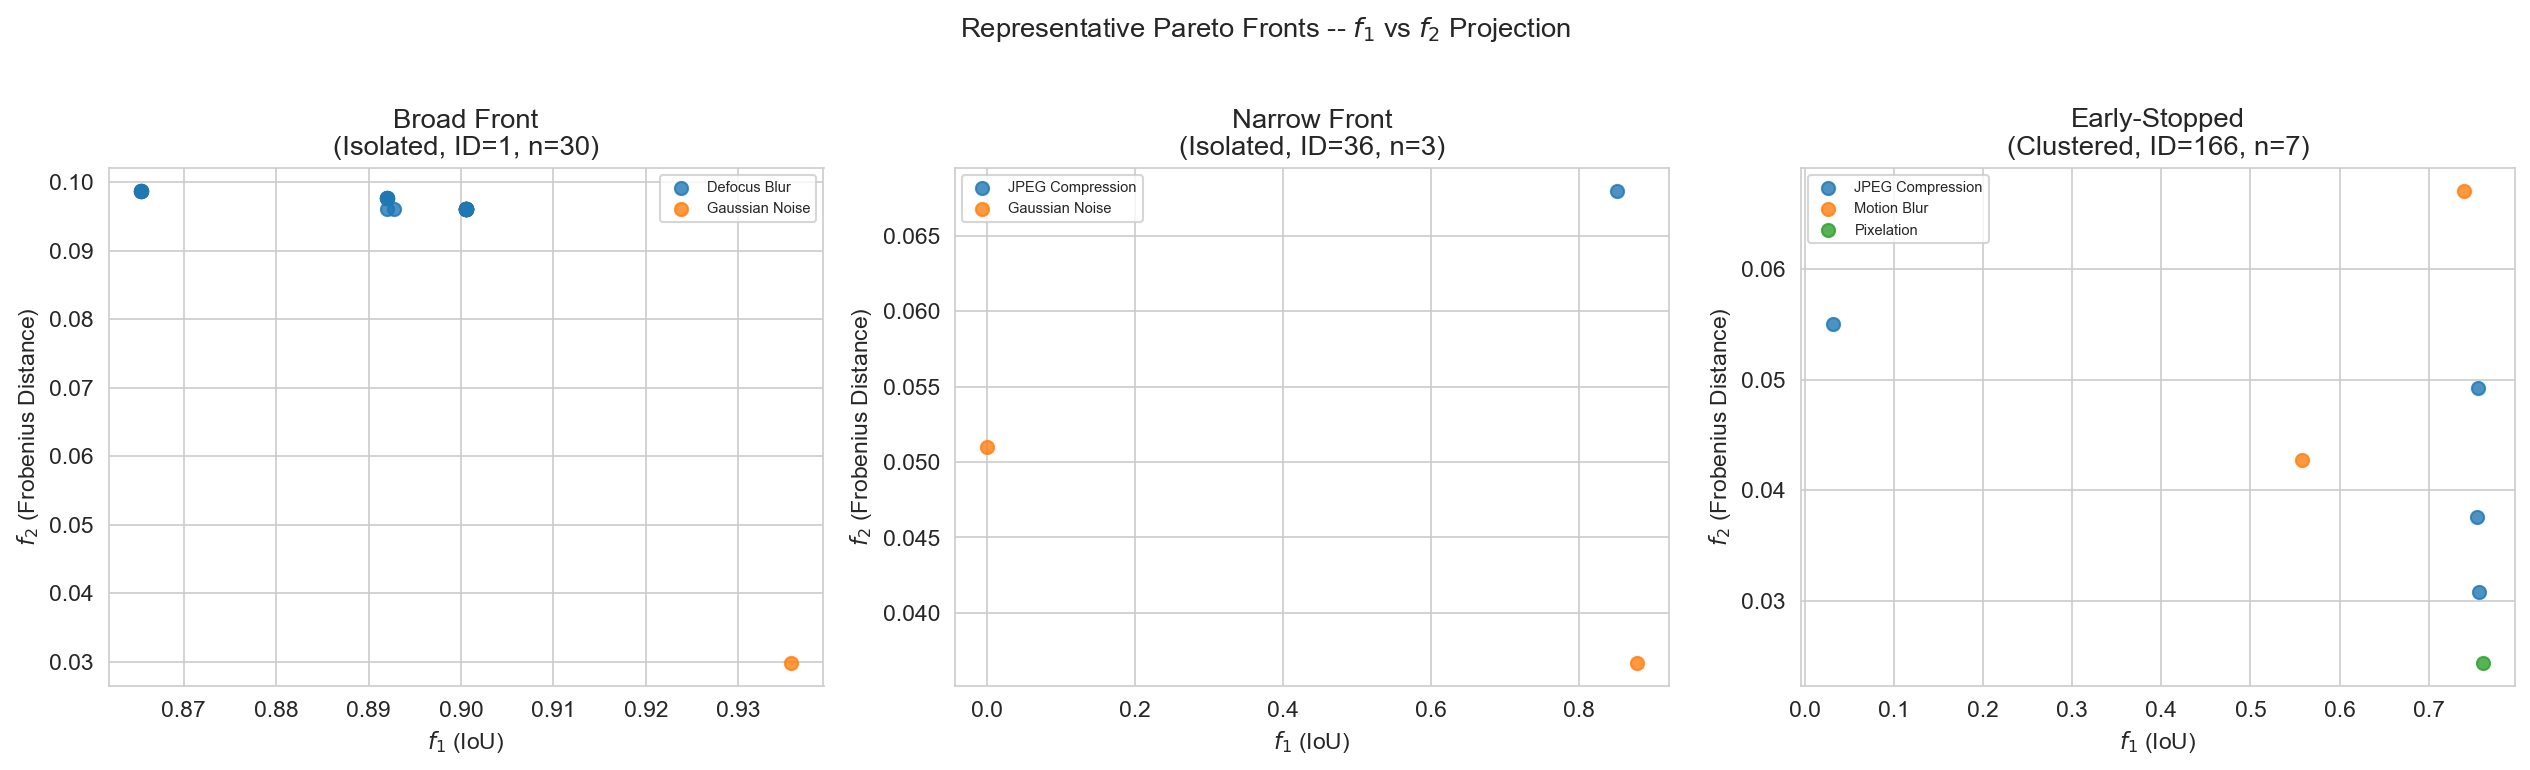

In [10]:
# ============================================================
# FIGURE 3: Representative Pareto fronts (3 examples)
#   a) Broad front with many trade-offs
#   b) Narrow/collapsed front
#   c) Early-stopped sample
# ============================================================

broad_sample = df_samples.nlargest(1, 'n_solutions').iloc[0]
narrow_sample = df_samples[df_samples.n_solutions <= 3].sample(1, random_state=42).iloc[0]
early_sample = df_samples[df_samples.early_stopped].sample(1, random_state=42).iloc[0]

examples = [
    (broad_sample,  'Broad Front'),
    (narrow_sample, 'Narrow Front'),
    (early_sample,  'Early-Stopped'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (sample, title_suffix) in zip(axes, examples):
    sid = sample['sample_id']
    st = sample['scene_type']
    sub = df_sols[(df_sols.sample_id == sid) & (df_sols.scene_type == st)]
    
    for img_atk in sub['img_attack'].unique():
        mask = sub.img_attack == img_atk
        ax.scatter(sub.loc[mask, 'iou'], sub.loc[mask, 'img_dist'],
                   s=40, alpha=0.8, label=IMG_NICE.get(img_atk, img_atk))

    ax.set_xlabel('$f_1$ (IoU)')
    ax.set_ylabel('$f_2$ (Frobenius Distance)')
    ax.set_title(f'{title_suffix}\n({st}, ID={sid}, n={len(sub)})')
    ax.legend(fontsize=7, loc='best')

plt.suptitle('Representative Pareto Fronts -- $f_1$ vs $f_2$ Projection', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_pareto_examples.pdf'))
plt.show()

## Detection Degradation Results

In [11]:
print('=== Detection Degradation (SWAD*-Optimal Solutions) ===')
print(f'{"Scene Type":<18} {"N":>4} {"BL IoU":>8} {"IoU_M":>8} {"δ_M+":>8} '
      f'{"IoU=0":>6} {"IoU<0.1":>7} {"IoU<0.35":>8}')
print('-' * 75)
for st in SCENE_ORDER:
    sub = df_samples[df_samples.scene_type == st]
    bl = sub['baseline_iou']
    iou_m = sub['swad_iou_m']
    delta = sub['swad_delta_m']
    n_zero = (iou_m == 0).sum()
    n_below01 = (iou_m < 0.1).sum()
    n_below035 = (iou_m <= 0.35).sum()
    print(f'{st:<18} {len(sub):>4} {bl.mean():>8.3f} {iou_m.mean():>8.3f} '
          f'{delta.mean():>8.3f} {n_zero:>6} {n_below01:>7} {n_below035:>8}')

ovr = df_samples
print('-' * 75)
print(f'{"Overall":<18} {len(ovr):>4} {ovr.baseline_iou.mean():>8.3f} '
      f'{ovr.swad_iou_m.mean():>8.3f} {ovr.swad_delta_m.mean():>8.3f} '
      f'{(ovr.swad_iou_m==0).sum():>6} {(ovr.swad_iou_m<0.1).sum():>7} '
      f'{(ovr.swad_iou_m<=0.35).sum():>8}')

=== Detection Degradation (SWAD*-Optimal Solutions) ===
Scene Type            N   BL IoU    IoU_M     δ_M+  IoU=0 IoU<0.1 IoU<0.35
---------------------------------------------------------------------------
Isolated            250    0.923    0.208    0.774     83     152      193
Clustered           250    0.841    0.121    0.851     86     160      228
Mixed               250    0.782    0.059    0.919    180     191      247
---------------------------------------------------------------------------
Overall             750    0.849    0.130    0.848    349     503      668


In [12]:
print('\n=== IoU_M Distribution (SWAD*-Optimal) ===')
print(f'{"Scene Type":<18} {"Mean":>7} {"Std":>7} {"Median":>7} {"Q25":>7} {"Q75":>7}')
print('-' * 55)
for st in SCENE_ORDER:
    v = df_samples[df_samples.scene_type == st]['swad_iou_m']
    print(f'{st:<18} {v.mean():>7.3f} {v.std():>7.3f} {v.median():>7.3f} '
          f'{v.quantile(0.25):>7.3f} {v.quantile(0.75):>7.3f}')
v = df_samples['swad_iou_m']
print('-' * 55)
print(f'{"Overall":<18} {v.mean():>7.3f} {v.std():>7.3f} {v.median():>7.3f} '
      f'{v.quantile(0.25):>7.3f} {v.quantile(0.75):>7.3f}')


=== IoU_M Distribution (SWAD*-Optimal) ===
Scene Type            Mean     Std  Median     Q25     Q75
-------------------------------------------------------
Isolated             0.208   0.302   0.030   0.000   0.305
Clustered            0.121   0.164   0.031   0.000   0.230
Mixed                0.059   0.110   0.000   0.000   0.053
-------------------------------------------------------
Overall              0.130   0.217   0.007   0.000   0.209


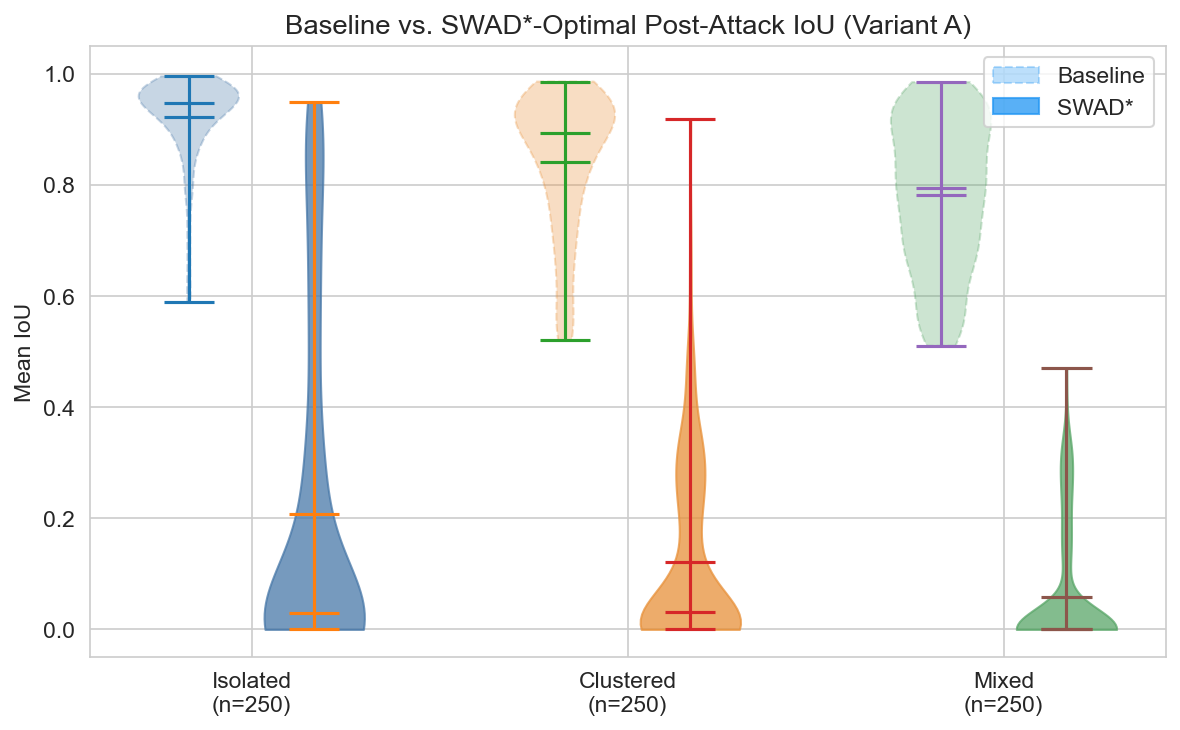

In [13]:
# ============================================================
# FIGURE 4: Paired violin/box -- baseline IoU vs. post-attack IoU (SWAD*)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

positions_bl  = [1, 4, 7]
positions_atk = [2, 5, 8]

BL_ALPHA = 0.3
ATK_ALPHA = 0.75

for i, st in enumerate(SCENE_ORDER):
    sub = df_samples[df_samples.scene_type == st]
    col = SCENE_COLORS[st]
    
    vp1 = ax.violinplot(sub['baseline_iou'], positions=[positions_bl[i]],
                        showmeans=True, showmedians=True, widths=0.8)
    for pc in vp1['bodies']:
        pc.set_facecolor(col)
        pc.set_alpha(BL_ALPHA)
        pc.set_edgecolor(col)
        pc.set_linestyle('--')
        
    vp2 = ax.violinplot(sub['swad_iou_m'], positions=[positions_atk[i]],
                        showmeans=True, showmedians=True, widths=0.8)
    for pc in vp2['bodies']:
        pc.set_facecolor(col)
        pc.set_alpha(ATK_ALPHA)
        pc.set_edgecolor(col)

ax.set_xticks([1.5, 4.5, 7.5])
ax.set_xticklabels([f'{st}\n(n=250)' for st in SCENE_ORDER])
ax.set_ylabel('Mean IoU')
ax.set_title('Baseline vs. SWAD*-Optimal Post-Attack IoU (Variant A)')

handles = [
    Patch(facecolor='#2196F3', alpha=BL_ALPHA, edgecolor='#2196F3',
          linestyle='--', label='Baseline'),
    Patch(facecolor='#2196F3', alpha=ATK_ALPHA, edgecolor='#2196F3',
          label='SWAD*'),
]
ax.legend(handles=handles, loc='upper right')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_degradation_violin_simple.pdf'))
plt.show()

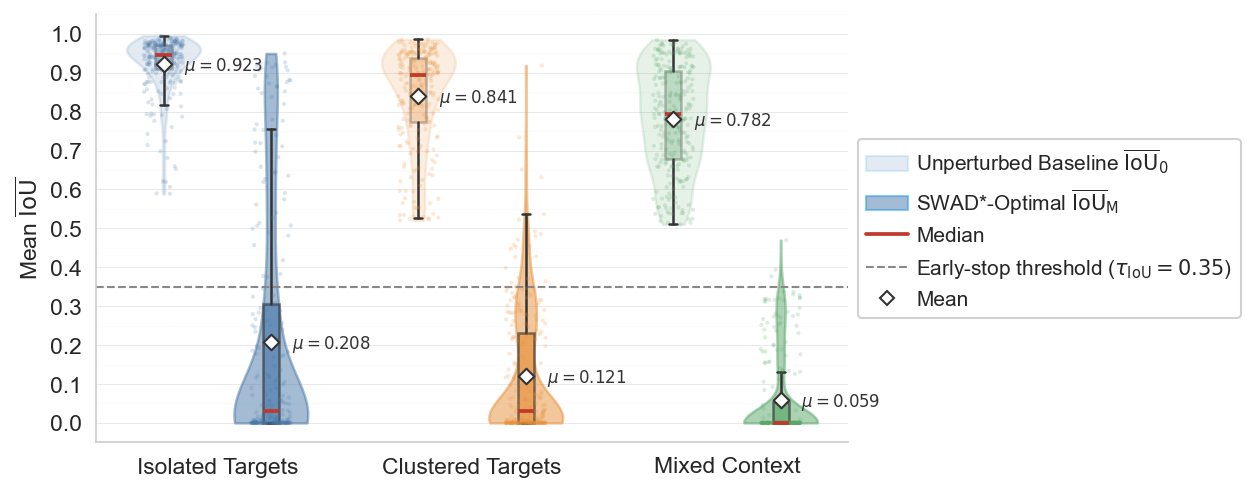

In [14]:
SCENE_LABELS = [
    "Isolated Targets",
    "Clustered Targets",
    "Mixed Context",
]

fig, ax = plt.subplots(figsize=(8.5, 3.55))

# Paired positions: baseline left, attack right within each group
positions_bl  = [1.0, 2.9, 4.8]
positions_atk = [1.8, 3.7, 5.6]
OFFSET = 0.35  # half-width for jitter

rng = np.random.default_rng(42)

for i, st in enumerate(SCENE_ORDER):
    sub = df_samples[df_samples.scene_type == st]
    col = SCENE_COLORS[st]
    bl_arr = sub['baseline_iou'].values
    atk_arr = sub['swad_iou_m'].values

    for arr, pos, alpha, ls in [
        (bl_arr, positions_bl[i], 0.15, '--'),
        (atk_arr, positions_atk[i], 0.50, '-'),
    ]:
        # Violin
        vp = ax.violinplot([arr], positions=[pos],
                           showmeans=False, showmedians=False,
                           showextrema=False, widths=0.55)
        for body in vp['bodies']:
            body.set_facecolor(col)
            body.set_edgecolor(col)
            body.set_alpha(alpha)
            body.set_linewidth(1.2)

        # Box plot overlay
        bp = ax.boxplot([arr], positions=[pos], widths=0.12,
                        patch_artist=True, showfliers=False, showcaps=True,
                        whiskerprops=dict(linewidth=1.2, color='#333'),
                        capprops=dict(linewidth=1.2, color='#333'),
                        medianprops=dict(linewidth=1.8, color='#C0392B', zorder=5),
                        boxprops=dict(linewidth=1.2))
        bp['boxes'][0].set_facecolor(col)
        bp['boxes'][0].set_alpha(alpha + 0.15)
        bp['boxes'][0].set_edgecolor('#333')

        # Jittered strip
        jitter = rng.uniform(-0.15, 0.15, size=len(arr))
        ax.scatter(pos + jitter, arr, s=4, alpha=0.20, color=col,
                   edgecolors='none', zorder=2, rasterized=True)

        # Mean diamond + annotation
        mu = np.mean(arr)
        ax.scatter(pos, mu, marker='D', s=28, color='white',
                   edgecolors='#333', linewidths=1.0, zorder=6)
        ax.annotate(f'$\\mu = {mu:.3f}$', xy=(pos, mu), xytext=(10, -1),
                    textcoords='offset points', fontsize=8, color='#333', va='center')

# Group labels
ax.set_xticks([(b + a) / 2 for b, a in zip(positions_bl, positions_atk)])
ax.set_xticklabels(SCENE_LABELS, linespacing=1.2)

# Threshold line
ax.axhline(y=0.35, color='#888', linestyle='--', linewidth=1.0, zorder=1)

# Axes
ax.set_ylabel('Mean $\\overline{\\mathrm{IoU}}$')
ax.set_ylim(-0.05, 1.05)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.4, alpha=0.5)
ax.yaxis.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.3)
ax.set_axisbelow(True)
ax.xaxis.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_elements = [
    Patch(facecolor='#4878A8', alpha=0.15, edgecolor='#2196F3',
          label='Unperturbed Baseline $\\overline{\\mathrm{IoU}}_0$'),
    Patch(facecolor='#4878A8', alpha=0.50, edgecolor='#2196F3',
          label='SWAD*-Optimal $\\overline{\\mathrm{IoU}}_\\mathrm{M}$'),
    Line2D([0], [0], color='#C0392B', linestyle='-', linewidth=1.8,
           label='Median'),
    Line2D([0], [0], color='#888', linestyle='--', linewidth=1.0,
           label='Early-stop threshold ($\\tau_{\\mathrm{IoU}} = 0.35$)'),
    Line2D([0], [0], marker='D', color='white', markeredgecolor='#333',
           markersize=5, linewidth=0, label='Mean'),
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.0, 0.5),
          ncol=1, frameon=True, framealpha=0.9, edgecolor='#ccc',
          fontsize=10, handletextpad=0.4)

fig.tight_layout()
fig.subplots_adjust(bottom=0.15)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_degradation_violin.pdf'))
plt.show()

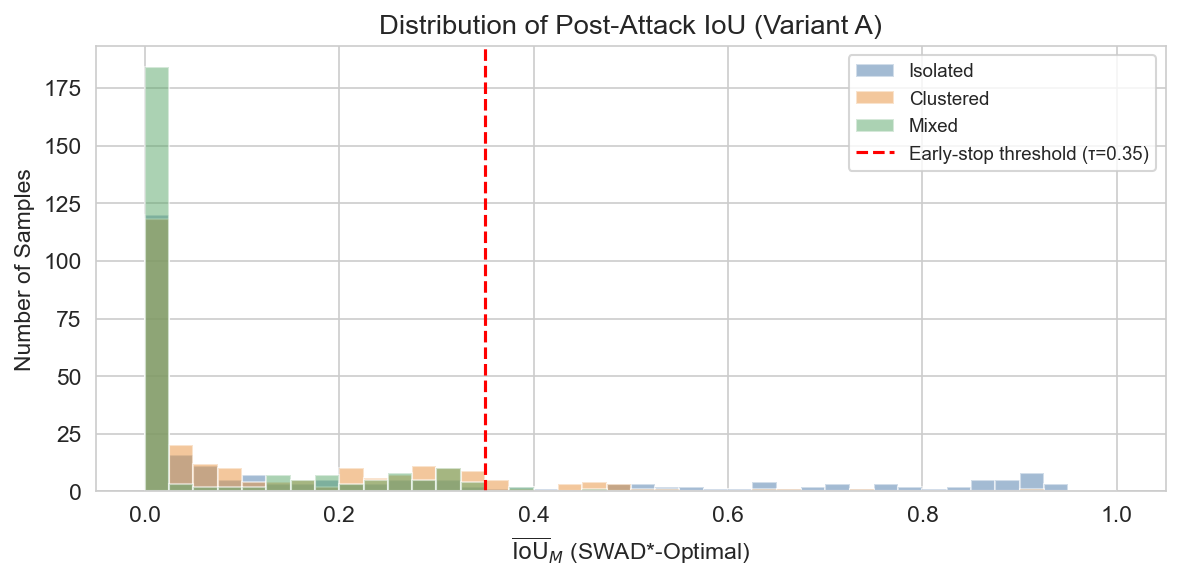

In [15]:
# ============================================================
# FIGURE 5: Histogram -- post-attack IoU distribution (SWAD*-optimal)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))

bins = np.linspace(0, 1, 41)
for st in SCENE_ORDER:
    vals = df_samples[df_samples.scene_type == st]['swad_iou_m']
    ax.hist(vals, bins=bins, alpha=0.5, label=st,
            color=SCENE_COLORS[st], edgecolor='white')

ax.axvline(0.35, color='red', ls='--', lw=1.5, label=f'Early-stop threshold (τ={EARLY_STOP_IOU_MAX})')
ax.set_xlabel('$\\overline{\\mathrm{IoU}}_M$ (SWAD*-Optimal)')
ax.set_ylabel('Number of Samples')
ax.set_title('Distribution of Post-Attack IoU (Variant A)')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_post_attack_iou_hist.pdf'))
plt.show()

## Stealth Analysis

In [16]:
print('=== Stealth Profile (SWAD*-Optimal Solutions) ===')
print(f'{"Scene Type":<18} {"d_I mean":>9} {"d_T mean":>9} {"Φ mean":>8} '
      f'{"Φ>0.8":>6} {"Φ>0.9":>6}')
print('-' * 60)
for st in SCENE_ORDER:
    sub = df_samples[df_samples.scene_type == st]
    di = sub['swad_img_dist']
    dt = sub['swad_txt_dist']
    phi = sub['swad_phi']
    print(f'{st:<18} {di.mean():>9.4f} {dt.mean():>9.4f} {phi.mean():>8.4f} '
          f'{(phi > 0.8).sum():>6} {(phi > 0.9).sum():>6}')
sub = df_samples
print('-' * 60)
print(f'{"Overall":<18} {sub.swad_img_dist.mean():>9.4f} '
      f'{sub.swad_txt_dist.mean():>9.4f} {sub.swad_phi.mean():>8.4f} '
      f'{(sub.swad_phi > 0.8).sum():>6} {(sub.swad_phi > 0.9).sum():>6}')

=== Stealth Profile (SWAD*-Optimal Solutions) ===
Scene Type          d_I mean  d_T mean   Φ mean  Φ>0.8  Φ>0.9
------------------------------------------------------------
Isolated              0.0672    0.1976   0.7457     90     41
Clustered             0.0627    0.2095   0.7399     72     39
Mixed                 0.0698    0.2083   0.7365     47     14
------------------------------------------------------------
Overall               0.0666    0.2051   0.7407    209     94


In [17]:
print('\n=== Stealth Frontier: Lowest Achievable IoU at Φ Thresholds ===')
for phi_thresh in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    mask = df_samples['swad_phi'] > phi_thresh
    if mask.sum() == 0:
        print(f'  Φ > {phi_thresh:.2f}: no solutions')
    else:
        sub = df_samples.loc[mask, 'swad_iou_m']
        print(f'  Φ > {phi_thresh:.2f}: n={mask.sum():>4}, '
              f'min IoU_M={sub.min():.4f}, mean IoU_M={sub.mean():.4f}')


=== Stealth Frontier: Lowest Achievable IoU at Φ Thresholds ===
  Φ > 0.50: n= 747, min IoU_M=0.0000, mean IoU_M=0.1300
  Φ > 0.60: n= 684, min IoU_M=0.0000, mean IoU_M=0.1393
  Φ > 0.70: n= 431, min IoU_M=0.0000, mean IoU_M=0.1886
  Φ > 0.80: n= 209, min IoU_M=0.0000, mean IoU_M=0.2992
  Φ > 0.90: n=  94, min IoU_M=0.0000, mean IoU_M=0.3965
  Φ > 0.95: n=  30, min IoU_M=0.0000, mean IoU_M=0.2808


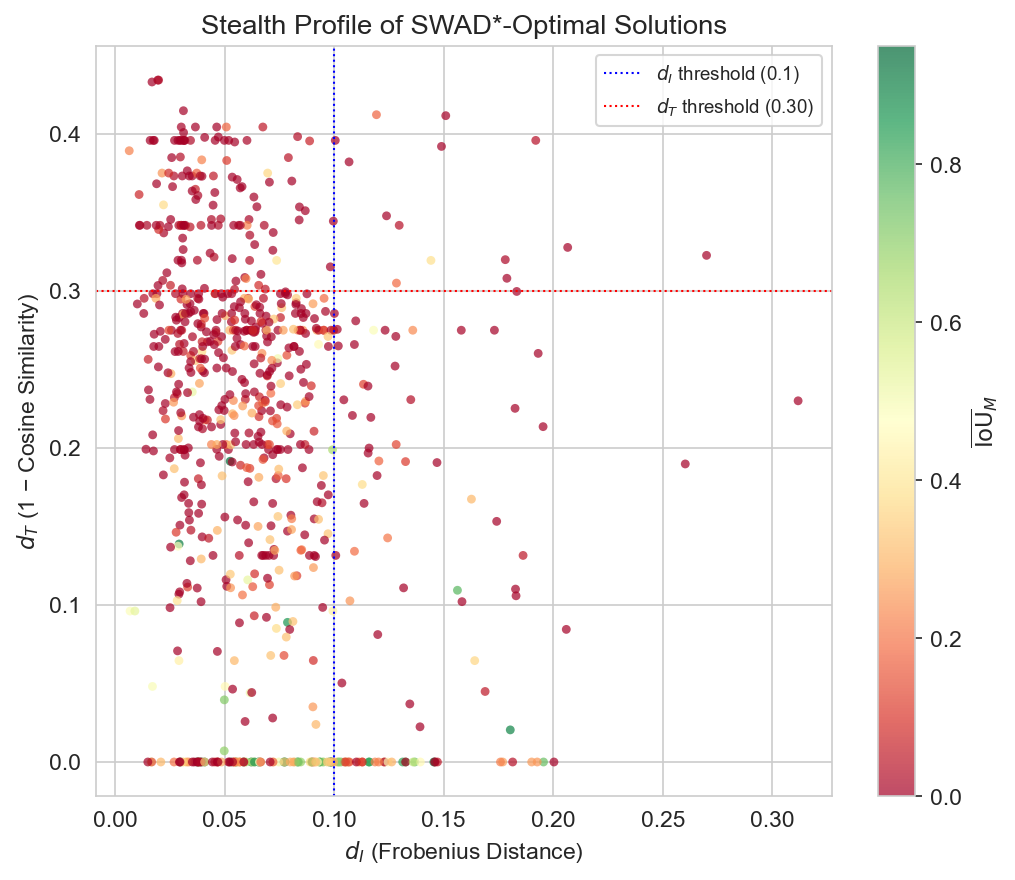

In [18]:
# ============================================================
# FIGURE 6: 2D scatter -- d_I vs d_T for SWAD*-optimal solutions
#           colored by IoU_M
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    df_samples['swad_img_dist'],
    df_samples['swad_txt_dist'],
    c=df_samples['swad_iou_m'],
    cmap='RdYlGn', s=18, alpha=0.7, edgecolors='none'
)
cbar = plt.colorbar(sc, ax=ax, label='$\\overline{\\mathrm{IoU}}_M$')

ax.axvline(EARLY_STOP_IMG_DIST_MAX, color='blue', ls=':', lw=1,
           label=f'$d_I$ threshold ({EARLY_STOP_IMG_DIST_MAX})')
ax.axhline(1 - EARLY_STOP_TXT_SIM_MIN, color='red', ls=':', lw=1,
           label=f'$d_T$ threshold ({1 - EARLY_STOP_TXT_SIM_MIN:.2f})')

ax.set_xlabel('$d_I$ (Frobenius Distance)')
ax.set_ylabel('$d_T$ (1 − Cosine Similarity)')
ax.set_title('Stealth Profile of SWAD*-Optimal Solutions')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_stealth_scatter.pdf'))
plt.show()

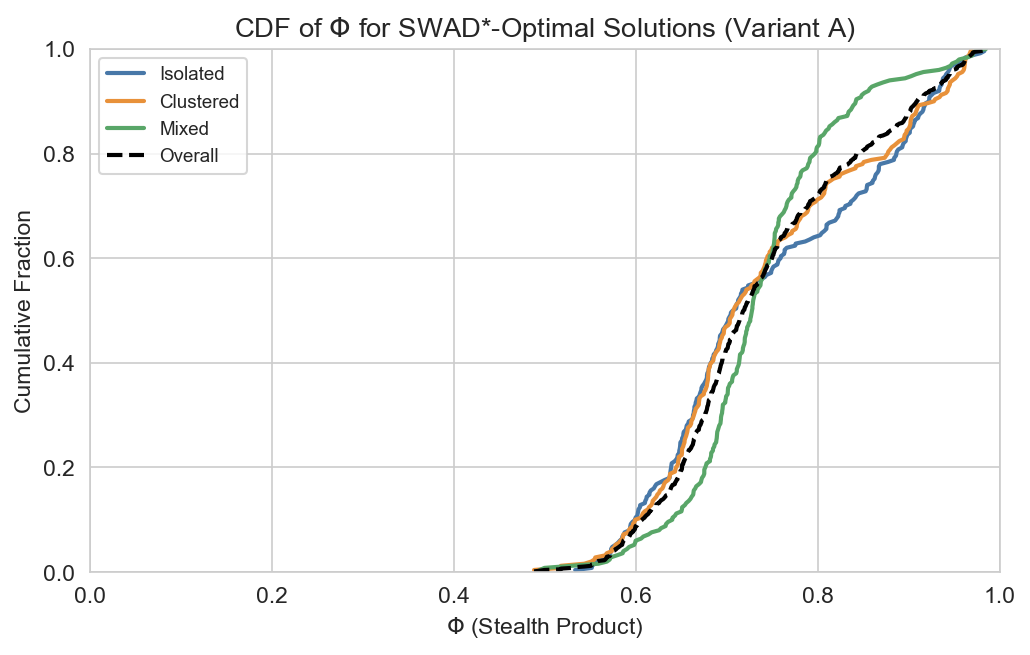

In [19]:
# ============================================================
# FIGURE 7: CDF of stealth product Φ (SWAD*-optimal solutions)
# ============================================================

fig, ax = plt.subplots(figsize=(7, 4.5))

for st in SCENE_ORDER:
    vals = np.sort(df_samples[df_samples.scene_type == st]['swad_phi'])
    cdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf, color=SCENE_COLORS[st], lw=2, label=st)

vals = np.sort(df_samples['swad_phi'])
cdf = np.arange(1, len(vals) + 1) / len(vals)
ax.plot(vals, cdf, color='black', lw=2, ls='--', label='Overall')

ax.set_xlabel('$\\Phi$ (Stealth Product)')
ax.set_ylabel('Cumulative Fraction')
ax.set_title('CDF of $\\Phi$ for SWAD*-Optimal Solutions (Variant A)')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_phi_cdf.pdf'))
plt.show()

## SWAD and SWAD* Results

In [20]:
print('=== SWAD* Distribution ===')
print(f'{"Scene Type":<18} {"Mean":>7} {"Std":>7} {"Median":>7} {"Q25":>7} {"Q75":>7} '
      f'{"Min":>7} {"Max":>7}')
print('-' * 70)
for st in SCENE_ORDER:
    v = df_samples[df_samples.scene_type == st]['swad_star']
    print(f'{st:<18} {v.mean():>7.4f} {v.std():>7.4f} {v.median():>7.4f} '
          f'{v.quantile(0.25):>7.4f} {v.quantile(0.75):>7.4f} '
          f'{v.min():>7.4f} {v.max():>7.4f}')
v = df_samples['swad_star']
print('-' * 70)
print(f'{"Overall":<18} {v.mean():>7.4f} {v.std():>7.4f} {v.median():>7.4f} '
      f'{v.quantile(0.25):>7.4f} {v.quantile(0.75):>7.4f} '
      f'{v.min():>7.4f} {v.max():>7.4f}')

=== SWAD* Distribution ===
Scene Type            Mean     Std  Median     Q25     Q75     Min     Max
----------------------------------------------------------------------
Isolated            0.5501  0.2195  0.6154  0.4788  0.6820  0.0062  0.9339
Clustered           0.6206  0.1496  0.6379  0.5378  0.7120  0.0488  0.9638
Mixed               0.6744  0.1275  0.6935  0.5986  0.7512  0.3502  0.9850
----------------------------------------------------------------------
Overall             0.6151  0.1773  0.6492  0.5449  0.7199  0.0062  0.9850


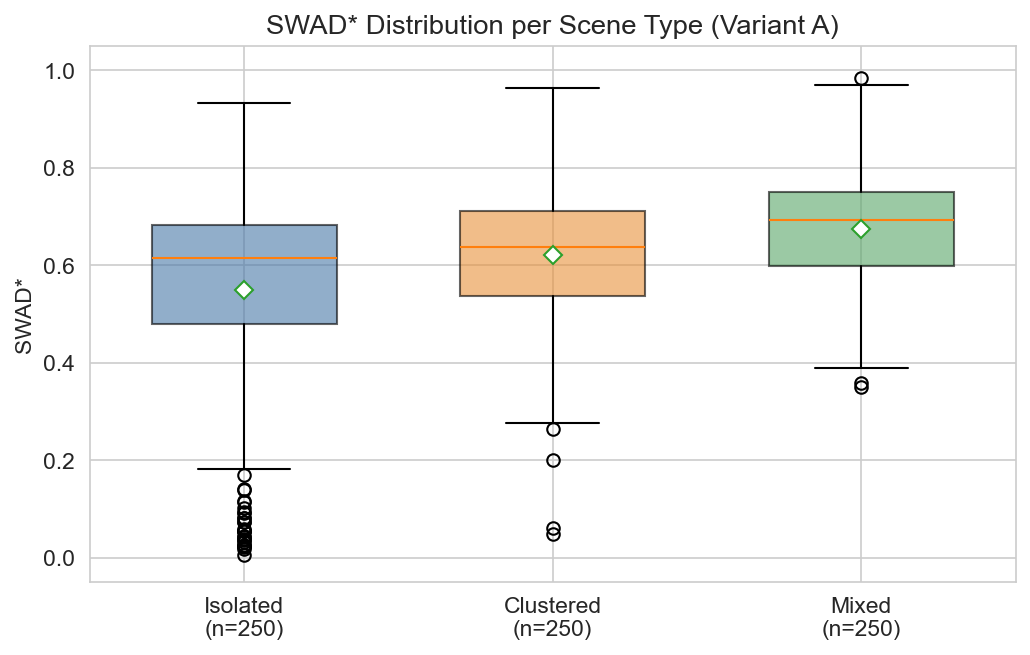

In [21]:
# ============================================================
# FIGURE 8: Box plot -- SWAD* distribution per scene type
# ============================================================

fig, ax = plt.subplots(figsize=(7, 4.5))

data = [df_samples[df_samples.scene_type == st]['swad_star'] for st in SCENE_ORDER]
bp = ax.boxplot(
    data, positions=[1, 2, 3], widths=0.6, patch_artist=True,
    showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markersize=6)
)
for patch, st in zip(bp['boxes'], SCENE_ORDER):
    patch.set_facecolor(SCENE_COLORS[st])
    patch.set_alpha(0.6)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels([f'{st}\n(n=250)' for st in SCENE_ORDER])
ax.set_ylabel('SWAD*')
ax.set_title('SWAD* Distribution per Scene Type (Variant A)')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_swad_star_boxplot.pdf'))
plt.show()

In [22]:
pairing_counts = df_samples.groupby(['swad_img_attack', 'swad_txt_attack']).size()
pairing_counts = pairing_counts.reset_index(name='count')
pairing_counts = pairing_counts.sort_values('count', ascending=False)

print('=== Top-10 Most Frequent SWAD*-Optimal Pairings ===')
print(f'{"Image Attack":<20} {"Text Attack":<20} {"Count":>6} {"Pct":>6}')
print('-' * 55)
for _, row in pairing_counts.head(10).iterrows():
    pct = 100 * row['count'] / len(df_samples)
    print(f'{IMG_NICE.get(row.swad_img_attack, row.swad_img_attack):<20} '
          f'{TXT_NICE.get(row.swad_txt_attack, row.swad_txt_attack):<20} '
          f'{row["count"]:>6} {pct:>5.1f}%')

=== Top-10 Most Frequent SWAD*-Optimal Pairings ===
Image Attack         Text Attack           Count    Pct
-------------------------------------------------------
Pixelation           Homophone               115  15.3%
JPEG Compression     Homophone               113  15.1%
Pixelation           Lexical Saliency         76  10.1%
JPEG Compression     Lexical Saliency         70   9.3%
Motion Blur          Lexical Saliency         47   6.3%
Defocus Blur         Homophone                45   6.0%
Gaussian Noise       Homophone                32   4.3%
Defocus Blur         Character Noise          28   3.7%
Defocus Blur         Lexical Saliency         27   3.6%
Motion Blur          Homophone                24   3.2%


In [23]:
top_pairings = df_samples.groupby(['swad_img_attack', 'swad_txt_attack']).agg(
    n=('swad_star', 'size'),
    mean_swad=('swad_star', 'mean'),
    mean_iou_m=('swad_iou_m', 'mean'),
    mean_d_I=('swad_img_dist', 'mean'),
    mean_d_T=('swad_txt_dist', 'mean'),
).reset_index().sort_values('n', ascending=False)

print('\n=== Top-5 Pairings: Full Metric Profile ===')
print(f'{"Image":<18} {"Text":<16} {"n":>4} {"SWAD*":>7} {"IoU_M":>7} '
      f'{"d_I":>7} {"d_T":>7}')
print('-' * 70)
for _, row in top_pairings.head(5).iterrows():
    print(f'{IMG_NICE.get(row.swad_img_attack, row.swad_img_attack):<18} '
          f'{TXT_NICE.get(row.swad_txt_attack, row.swad_txt_attack):<16} '
          f'{row.n:>4} {row.mean_swad:>7.4f} {row.mean_iou_m:>7.4f} '
          f'{row.mean_d_I:>7.4f} {row.mean_d_T:>7.4f}')


=== Top-5 Pairings: Full Metric Profile ===
Image              Text                n   SWAD*   IoU_M     d_I     d_T
----------------------------------------------------------------------
Pixelation         Homophone         115  0.6021  0.1362  0.0771  0.2032
JPEG Compression   Homophone         113  0.6276  0.1035  0.0642  0.2217
Pixelation         Lexical Saliency   76  0.5878  0.1360  0.0514  0.2428
JPEG Compression   Lexical Saliency   70  0.6531  0.0980  0.0534  0.2100
Motion Blur        Lexical Saliency   47  0.6463  0.0951  0.0504  0.2289


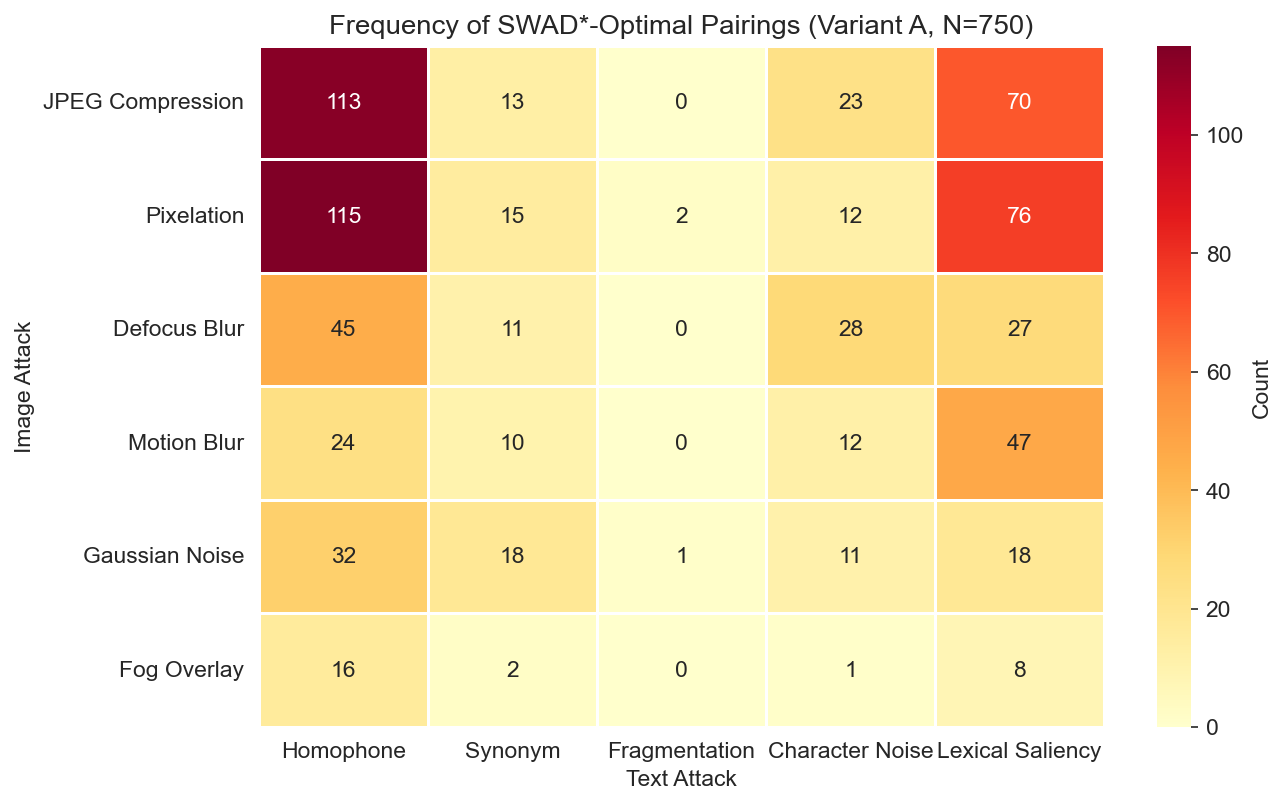

In [24]:
# ============================================================
# FIGURE 9: Heatmap -- SWAD*-optimal pairing frequency
#           (image attack rows × text attack columns)
# ============================================================

pivot_freq = df_samples.pivot_table(
    index='swad_img_attack', columns='swad_txt_attack',
    values='swad_star', aggfunc='count', fill_value=0
)
pivot_freq = pivot_freq.reindex(index=IMAGE_ATTACKS, columns=TEXT_ATTACKS, fill_value=0)
pivot_freq.index = [IMG_NICE[a] for a in pivot_freq.index]
pivot_freq.columns = [TXT_NICE[a] for a in pivot_freq.columns]

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(pivot_freq, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Frequency of SWAD*-Optimal Pairings (Variant A, N=750)')
ax.set_ylabel('Image Attack')
ax.set_xlabel('Text Attack')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_pairing_frequency_heatmap.pdf'))
plt.show()

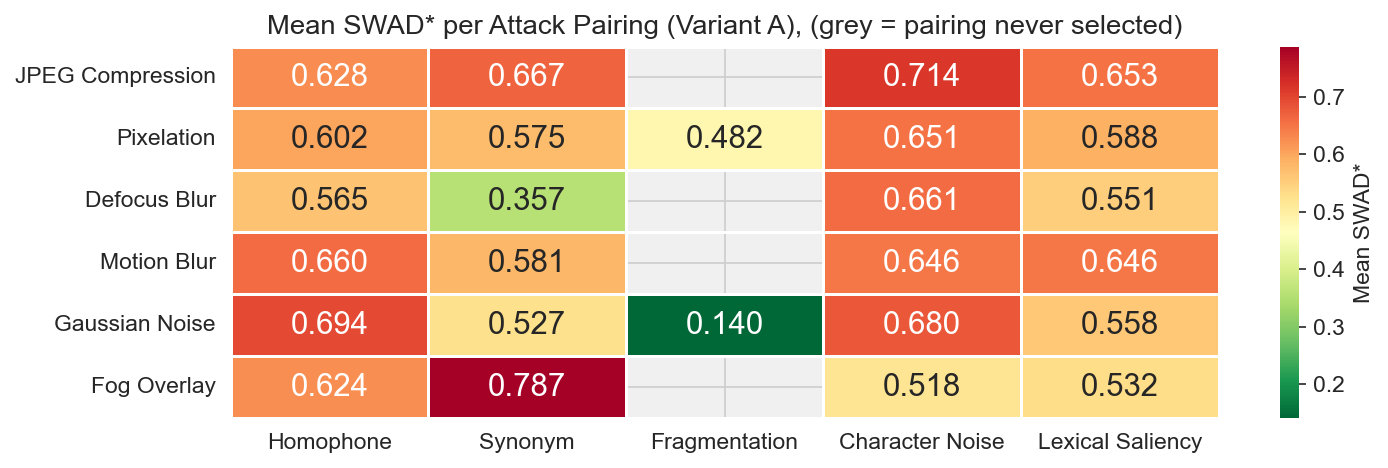

In [25]:
# ============================================================
# FIGURE 10: Heatmap -- mean SWAD* per pairing
# ============================================================

pivot_swad = df_samples.pivot_table(
    index='swad_img_attack', columns='swad_txt_attack',
    values='swad_star', aggfunc='mean'
)
pivot_swad = pivot_swad.reindex(index=IMAGE_ATTACKS, columns=TEXT_ATTACKS)
pivot_swad.index = [IMG_NICE[a] for a in pivot_swad.index]
pivot_swad.columns = [TXT_NICE[a] for a in pivot_swad.columns]

fig, ax = plt.subplots(figsize=(10, 3.25))
sns.heatmap(pivot_swad, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean SWAD*'},
            mask=pivot_swad.isna(), annot_kws={'fontsize': 15})
ax.set_facecolor('#f0f0f0')
ax.set_title('Mean SWAD* per Attack Pairing (Variant A), (grey = pairing never selected)')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_pairing_swad_heatmap.pdf'))
plt.show()

## Unimodal Reference Comparison

In [26]:
df_img_uni = pd.read_csv(VISUAL_CSV)
df_txt_uni = pd.read_csv(TEXTUAL_CSV)

bl = pd.read_csv(BASELINE_CSV).rename(columns={'iou': 'baseline_iou'})
bl_lookup = bl.set_index(['scene_type', 'sample_id'])['baseline_iou'].to_dict()

if 'baseline_iou' not in df_img_uni.columns:
    df_img_uni['baseline_iou'] = df_img_uni.apply(
        lambda r: bl_lookup.get((r['scene_type'], r['sample_id']), np.nan), axis=1)
if 'baseline_iou' not in df_txt_uni.columns:
    df_txt_uni['baseline_iou'] = df_txt_uni.apply(
        lambda r: bl_lookup.get((r['scene_type'], r['sample_id']), np.nan), axis=1)

print(f'Unimodal visual: {len(df_img_uni):,} rows ({df_img_uni.corruption.nunique()} corruptions)')
print(f'Unimodal textual: {len(df_txt_uni):,} rows ({df_txt_uni.corruption.nunique()} corruptions)')

Unimodal visual: 45,000 rows (12 corruptions)
Unimodal textual: 30,000 rows (8 corruptions)


In [27]:
# --- Build per-sample unimodal lookup ---
# Key: (scene_type, sample_id, corruption, severity) -> IoU
SEVERITY_ANCHORS = np.array([0.0, 0.25, 0.5, 0.75, 1.0])

img_uni_lookup = df_img_uni.set_index(
    ['scene_type', 'sample_id', 'corruption', 'severity']
)['IoU'].to_dict()

txt_uni_lookup = df_txt_uni.set_index(
    ['scene_type', 'sample_id', 'corruption', 'severity']
)['IoU'].to_dict()


def interpolate_unimodal_iou(lookup, scene_type, sample_id, corruption, continuous_severity):
    """
    Linearly interpolate per-sample unimodal IoU at a continuous severity
    using the 5 discrete anchor points from the unimodal evaluation.
    """
    S = np.clip(continuous_severity, 0.0, 1.0)
    
    # Find bracketing anchors
    idx_high = np.searchsorted(SEVERITY_ANCHORS, S, side='right')
    idx_high = min(idx_high, len(SEVERITY_ANCHORS) - 1)
    idx_low = max(0, idx_high - 1)
    
    S_low = SEVERITY_ANCHORS[idx_low]
    S_high = SEVERITY_ANCHORS[idx_high]
    
    # Map severity anchors to integer keys used in unimodal data
    sev_low = int(round(S_low * 4))
    sev_high = int(round(S_high * 4))
    
    iou_low = lookup.get((scene_type, sample_id, corruption, sev_low))
    iou_high = lookup.get((scene_type, sample_id, corruption, sev_high))
    
    if iou_low is None or iou_high is None:
        return None
    
    if S_low == S_high:
        return iou_low
    
    # Linear interpolation
    t = (S - S_low) / (S_high - S_low)
    return iou_low + t * (iou_high - iou_low)


print('Lookup tables built.')

Lookup tables built.


In [28]:
# --- Compute per-sample expected independent degradation (additive reference) ---

rho_records = []
n_skipped = 0

for _, row in df_samples.iterrows():
    st = row['scene_type']
    sid = row['sample_id']
    iou_0 = row['baseline_iou']
    
    img_atk = row['swad_img_attack']
    img_sev = row['swad_img_scale']
    txt_atk = row['swad_txt_attack']
    txt_sev = row['swad_txt_scale']
    
    # Interpolate unimodal IoU
    iou_img_hat = interpolate_unimodal_iou(img_uni_lookup, st, sid, img_atk, img_sev)
    iou_txt_hat = interpolate_unimodal_iou(txt_uni_lookup, st, sid, txt_atk, txt_sev)
    
    if iou_img_hat is None or iou_txt_hat is None:
        n_skipped += 1
        continue
    
    # Per-sample unimodal degradation
    delta_img = max(0, (iou_0 - iou_img_hat) / iou_0) if iou_0 > 0 else 0
    delta_txt = max(0, (iou_0 - iou_txt_hat) / iou_0) if iou_0 > 0 else 0
    
    # Additive reference (probabilistic union under independence)
    delta_ref = delta_img + delta_txt - delta_img * delta_txt
    
    # Observed multimodal degradation
    delta_m_obs = row['swad_delta_m']
    
    # Excess degradation ratio
    if delta_ref > 0.05:  # require ≥5% expected degradation for meaningful ratio
        rho = delta_m_obs / delta_ref
    else:
        rho = np.nan  # undefined (near-zero reference makes ratio unstable)
    
    rho_records.append({
        'scene_type': st,
        'sample_id': sid,
        'iou_0': iou_0,
        'delta_img': delta_img,
        'delta_txt': delta_txt,
        'delta_ref': delta_ref,
        'delta_m_obs': delta_m_obs,
        'rho': rho,
        'img_attack': img_atk,
        'txt_attack': txt_atk,
        'img_scale': img_sev,
        'txt_scale': txt_sev,
    })

df_rho = pd.DataFrame(rho_records)
df_rho_valid = df_rho.dropna(subset=['rho'])

print(f'Computed additive reference for {len(df_rho)} samples')
print(f'Skipped (missing unimodal data): {n_skipped}')
print(f'Valid ρ values: {len(df_rho_valid)} (undefined excluded: {len(df_rho) - len(df_rho_valid)})')

Computed additive reference for 750 samples
Skipped (missing unimodal data): 0
Valid ρ values: 460 (undefined excluded: 290)


In [29]:
print('=== Excess Degradation Ratio (ρ) Statistics ===')
print(f'  (Excludes samples with δ_ref < 0.05 where the ratio is unstable)\n')
print(f'{"Scene Type":<18} {"N":>5} {"Mean ρ":>8} {"Med ρ":>8} {"Q25":>8} {"Q75":>8} '
      f'{"ρ>1":>5} {"ρ>1.5":>6}')
print('-' * 68)
for st in SCENE_ORDER:
    sub = df_rho_valid[df_rho_valid.scene_type == st]['rho']
    print(f'{st:<18} {len(sub):>5} {sub.mean():>8.3f} {sub.median():>8.3f} '
          f'{sub.quantile(0.25):>8.3f} {sub.quantile(0.75):>8.3f} '
          f'{(sub > 1).sum():>5} {(sub > 1.5).sum():>6}')
sub = df_rho_valid['rho']
print('-' * 68)
print(f'{"Overall":<18} {len(sub):>5} {sub.mean():>8.3f} {sub.median():>8.3f} '
      f'{sub.quantile(0.25):>8.3f} {sub.quantile(0.75):>8.3f} '
      f'{(sub > 1).sum():>5} {(sub > 1.5).sum():>6}')

n_excluded = len(df_rho) - len(df_rho_valid)
print(f'\nExcluded from ρ: {n_excluded} samples (δ_ref < 0.05)')

=== Excess Degradation Ratio (ρ) Statistics ===
  (Excludes samples with δ_ref < 0.05 where the ratio is unstable)

Scene Type             N   Mean ρ    Med ρ      Q25      Q75   ρ>1  ρ>1.5
--------------------------------------------------------------------
Isolated             116    3.961    2.230    1.172    4.506   105     68
Clustered            159    3.486    2.187    1.287    3.437   144    103
Mixed                185    3.429    2.179    1.460    4.152   172    135
--------------------------------------------------------------------
Overall              460    3.583    2.188    1.266    4.121   421    306

Excluded from ρ: 290 samples (δ_ref < 0.05)


In [30]:
rho_by_pairing = df_rho_valid.groupby(['img_attack', 'txt_attack']).agg(
    n=('rho', 'size'),
    mean_rho=('rho', 'mean'),
    med_rho=('rho', 'median'),
).reset_index().sort_values('mean_rho', ascending=False)

print('\n=== Mean ρ per Attack Pairing (SWAD*-Optimal, sorted by ρ) ===')
print(f'{"Image":<18} {"Text":<16} {"n":>4} {"Mean ρ":>8} {"Med ρ":>8}')
print('-' * 58)
for _, row in rho_by_pairing.head(10).iterrows():
    print(f'{IMG_NICE.get(row.img_attack, row.img_attack):<18} '
          f'{TXT_NICE.get(row.txt_attack, row.txt_attack):<16} '
          f'{row.n:>4} {row.mean_rho:>8.3f} {row.med_rho:>8.3f}')


=== Mean ρ per Attack Pairing (SWAD*-Optimal, sorted by ρ) ===
Image              Text                n   Mean ρ    Med ρ
----------------------------------------------------------
Fog Overlay        Synonym             1    7.101    7.101
JPEG Compression   Synonym             7    7.037    7.398
Motion Blur        Homophone           9    6.496    3.278
JPEG Compression   Character Noise    13    5.444    2.162
Pixelation         Character Noise     8    4.827    3.867
Gaussian Noise     Character Noise     8    4.497    2.553
Gaussian Noise     Homophone          14    4.326    2.598
Pixelation         Lexical Saliency   31    4.305    2.992
JPEG Compression   Lexical Saliency   45    4.239    2.492
Motion Blur        Lexical Saliency   29    4.002    2.321


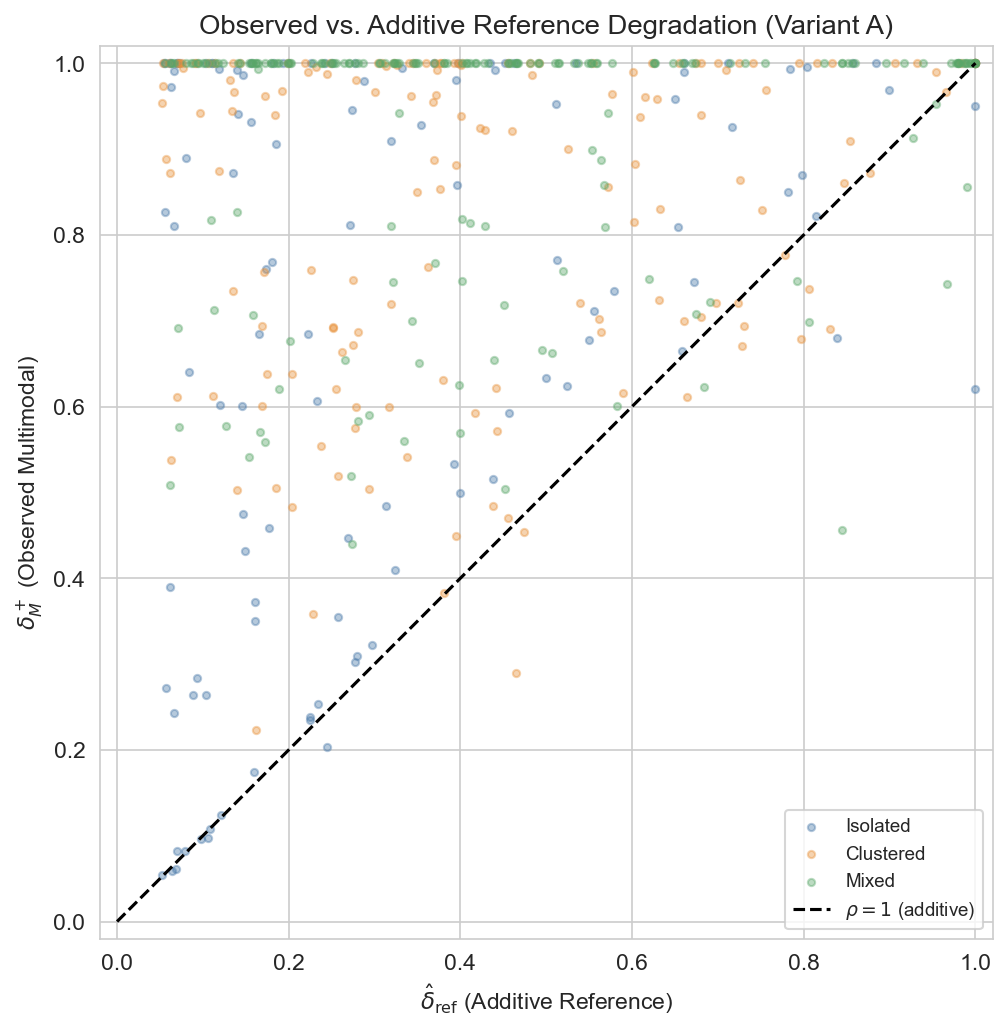

In [31]:
# ============================================================
# FIGURE 11: Scatter -- δ_ref (x) vs δ_M+ (y) with y=x reference
# ============================================================

fig, ax = plt.subplots(figsize=(7, 7))

for st in SCENE_ORDER:
    sub = df_rho_valid[df_rho_valid.scene_type == st]
    ax.scatter(sub['delta_ref'], sub['delta_m_obs'], s=12, alpha=0.4,
              color=SCENE_COLORS[st], label=st)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='$\\rho = 1$ (additive)')

ax.set_xlabel('$\\hat{\\delta}_{\\mathrm{ref}}$ (Additive Reference)')
ax.set_ylabel('$\\delta_M^+$ (Observed Multimodal)')
ax.set_title('Observed vs. Additive Reference Degradation (Variant A)')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_rho_scatter.pdf'))
plt.show()

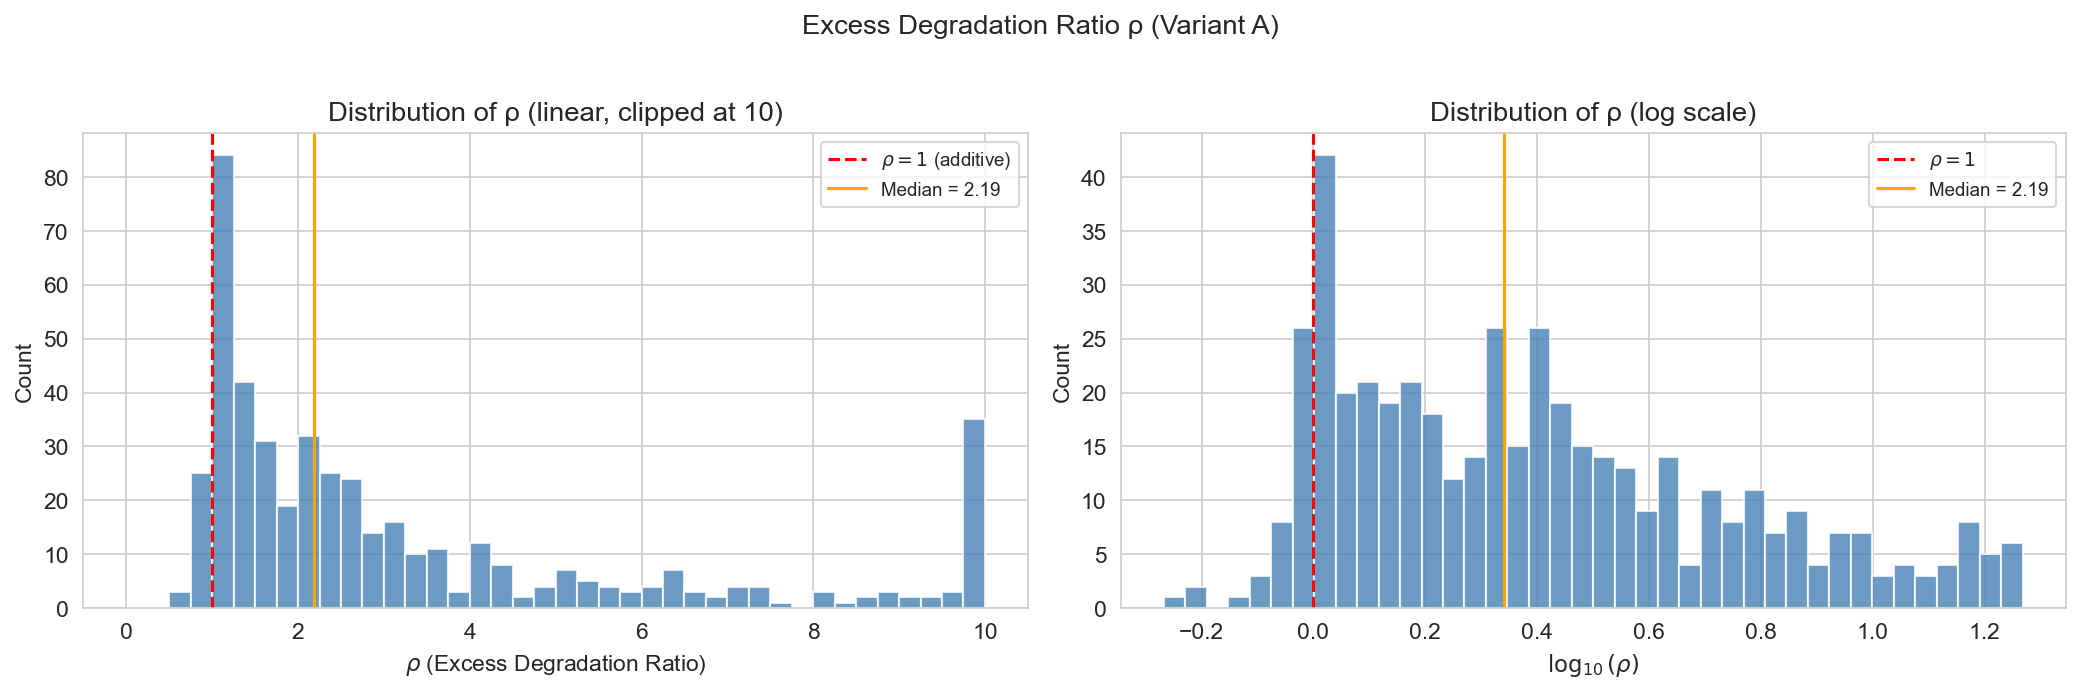

In [32]:
# ============================================================
# FIGURE 12: Histogram of ρ values
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
rho_clipped = df_rho_valid['rho'].clip(upper=10)
bins = np.linspace(0, 10, 41)
ax.hist(rho_clipped, bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='$\\rho = 1$ (additive)')
ax.axvline(df_rho_valid['rho'].median(), color='orange', ls='-', lw=1.5,
           label=f'Median = {df_rho_valid["rho"].median():.2f}')
ax.set_xlabel('$\\rho$ (Excess Degradation Ratio)')
ax.set_ylabel('Count')
ax.set_title('Distribution of ρ (linear, clipped at 10)')
ax.legend(fontsize=9)

ax = axes[1]
rho_pos = df_rho_valid['rho'][df_rho_valid['rho'] > 0]
ax.hist(np.log10(rho_pos), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', ls='--', lw=1.5, label='$\\rho = 1$')
ax.axvline(np.log10(df_rho_valid['rho'].median()), color='orange', ls='-', lw=1.5,
           label=f'Median = {df_rho_valid["rho"].median():.2f}')
ax.set_xlabel('$\\log_{10}(\\rho)$')
ax.set_ylabel('Count')
ax.set_title('Distribution of ρ (log scale)')
ax.legend(fontsize=9)

plt.suptitle('Excess Degradation Ratio ρ (Variant A)', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_rho_histogram.pdf'))
plt.show()

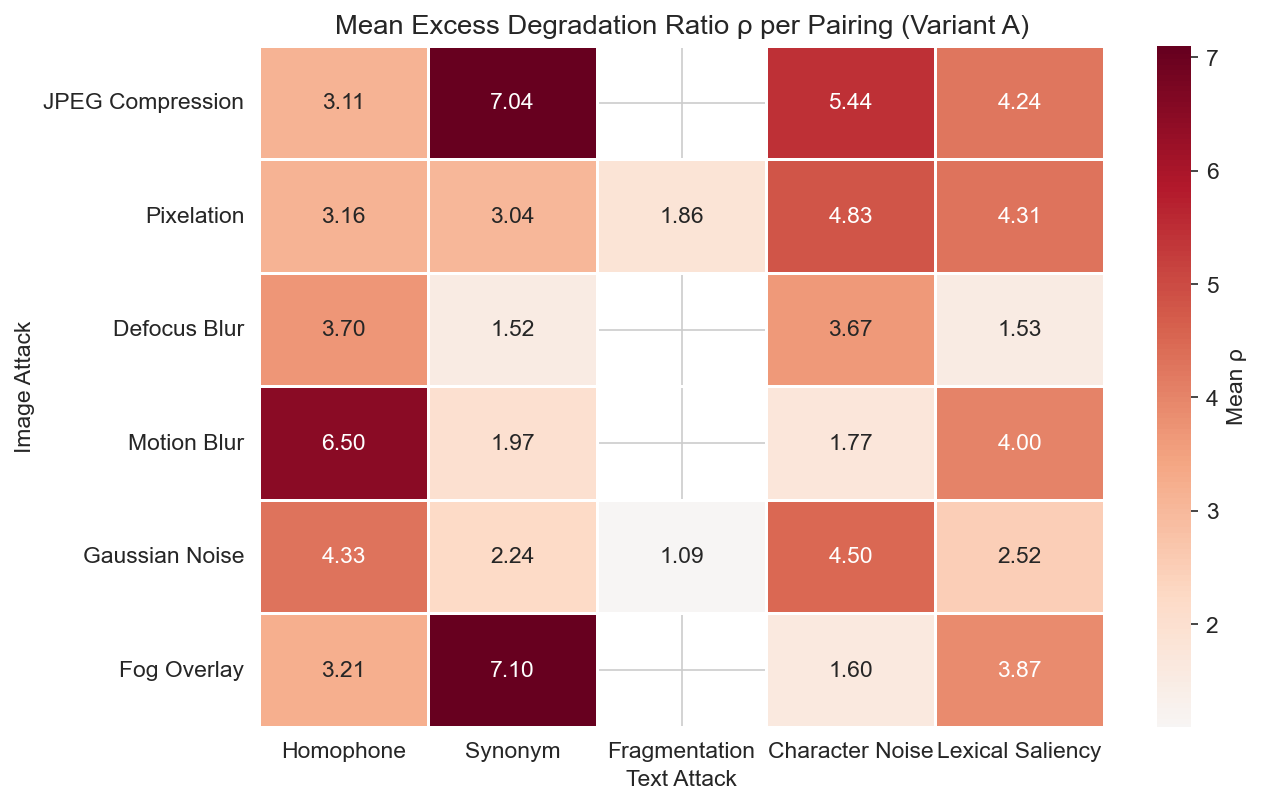

In [33]:
# ============================================================
# FIGURE 13: Heatmap -- mean ρ per pairing
# ============================================================

pivot_rho = df_rho_valid.pivot_table(
    index='img_attack', columns='txt_attack',
    values='rho', aggfunc='mean'
)
pivot_rho = pivot_rho.reindex(index=IMAGE_ATTACKS, columns=TEXT_ATTACKS)
pivot_rho.index = [IMG_NICE[a] for a in pivot_rho.index]
pivot_rho.columns = [TXT_NICE[a] for a in pivot_rho.columns]

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(pivot_rho, annot=True, fmt='.2f', cmap='RdBu_r', center=1.0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean ρ'})
ax.set_title('Mean Excess Degradation Ratio ρ per Pairing (Variant A)')
ax.set_ylabel('Image Attack')
ax.set_xlabel('Text Attack')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_rho_heatmap.pdf'))
plt.show()

## Early Stopping Behavior

In [34]:
print('=== Early Stopping Statistics ===')
n_es = df_samples['early_stopped'].sum()
print(f'Total early-stopped: {n_es}/{len(df_samples)} ({100*n_es/len(df_samples):.1f}%)\n')

print(f'{"Scene Type":<18} {"ES Count":>9} {"ES Rate":>8} {"Mean Gen":>9} '
      f'{"Med Gen":>8} {"Min Gen":>8} {"Max Gen":>8}')
print('-' * 72)
for st in SCENE_ORDER:
    sub = df_samples[df_samples.scene_type == st]
    es = sub[sub.early_stopped]
    n = len(es)
    rate = 100 * n / len(sub)
    if n > 0:
        gens = es['early_stop_gen']
        print(f'{st:<18} {n:>5}/{len(sub):<3} {rate:>7.1f}% {gens.mean():>9.1f} '
              f'{gens.median():>8.0f} {gens.min():>8} {gens.max():>8}')
    else:
        print(f'{st:<18} {n:>5}/{len(sub):<3} {rate:>7.1f}%       --        --        --        --')

=== Early Stopping Statistics ===
Total early-stopped: 548/750 (73.1%)

Scene Type          ES Count  ES Rate  Mean Gen  Med Gen  Min Gen  Max Gen
------------------------------------------------------------------------
Isolated             123/250    49.2%       4.4        3      1.0     15.0
Clustered            182/250    72.8%       3.7        2      1.0     15.0
Mixed                243/250    97.2%       2.0        1      1.0     14.0


In [35]:
es_mask = df_samples['early_stopped']
print('\n=== SWAD* Quality: Early-Stopped vs. Full-Run ===')
print(f'{"Group":<18} {"N":>5} {"Mean SWAD*":>11} {"Med SWAD*":>11} {"Mean IoU_M":>11}')
print('-' * 60)
for label, mask in [('Early-stopped', es_mask), ('Full-run', ~es_mask)]:
    sub = df_samples[mask]
    if len(sub) > 0:
        print(f'{label:<18} {len(sub):>5} {sub.swad_star.mean():>11.4f} '
              f'{sub.swad_star.median():>11.4f} {sub.swad_iou_m.mean():>11.4f}')
    else:
        print(f'{label:<18}     0          --            --            --')

for st in SCENE_ORDER:
    sub = df_samples[df_samples['scene_type'] == st]
    es = sub[sub['early_stopped']]
    fr = sub[~sub['early_stopped']]
    print(f'{st:<18} ES: {len(es):>3}  SWAD*={es["swad_star"].mean():.4f}   '
          f'Full: {len(fr):>3}  SWAD*={fr["swad_star"].mean():.4f}')


=== SWAD* Quality: Early-Stopped vs. Full-Run ===
Group                  N  Mean SWAD*   Med SWAD*  Mean IoU_M
------------------------------------------------------------
Early-stopped        548      0.6694      0.6817      0.0745
Full-run             202      0.4676      0.5679      0.2788
Isolated           ES: 123  SWAD*=0.6723   Full: 127  SWAD*=0.4318
Clustered          ES: 182  SWAD*=0.6563   Full:  68  SWAD*=0.5249
Mixed              ES: 243  SWAD*=0.6777   Full:   7  SWAD*=0.5596


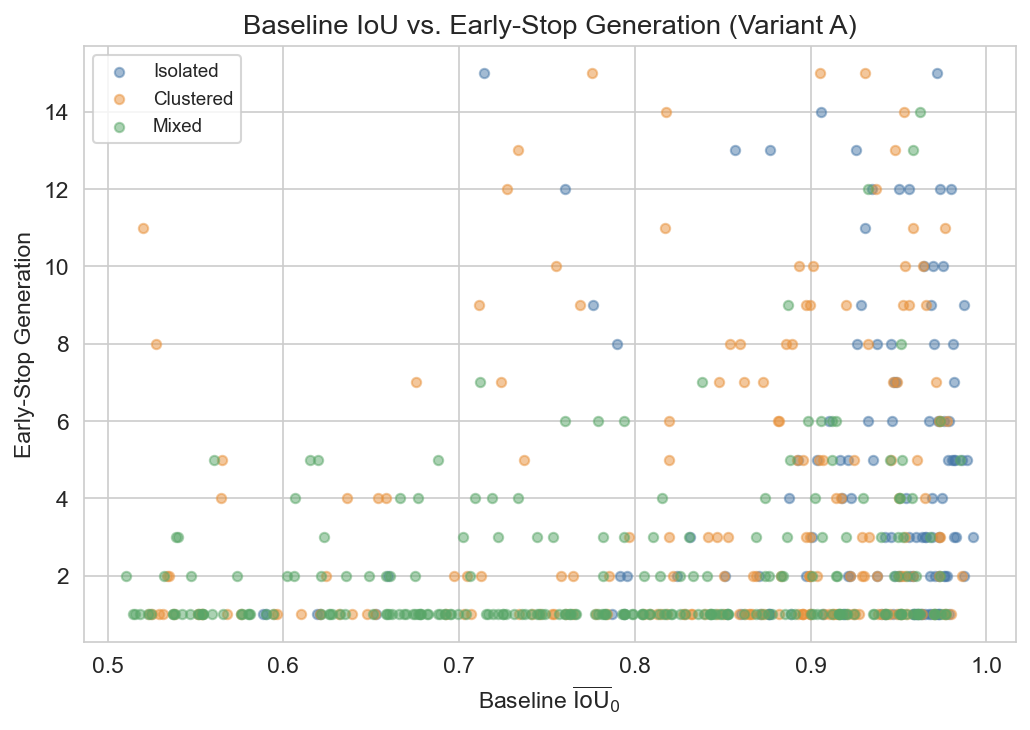

In [36]:
# ============================================================
# FIGURE 14: Scatter -- baseline IoU vs. early-stop generation
# ============================================================

es_data = df_samples[df_samples.early_stopped].copy()

if len(es_data) > 0:
    fig, ax = plt.subplots(figsize=(7, 5))
    
    for st in SCENE_ORDER:
        sub = es_data[es_data.scene_type == st]
        ax.scatter(sub['baseline_iou'], sub['early_stop_gen'],
                   s=20, alpha=0.5, color=SCENE_COLORS[st], label=st)
    
    ax.set_xlabel('Baseline $\\overline{\\mathrm{IoU}}_0$')
    ax.set_ylabel('Early-Stop Generation')
    ax.set_title('Baseline IoU vs. Early-Stop Generation (Variant A)')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'fig_early_stop_scatter.pdf'))
    plt.show()
else:
    print('No early-stopped samples -- skipping figure.')

In [37]:
print('\n=== Evaluation Count Statistics ===')
print(f'{"Scene Type":<18} {"Mean Evals":>11} {"Mean Skipped":>13} '
      f'{"Total (mean)":>13}')
print('-' * 58)
for st in SCENE_ORDER:
    sub = df_samples[df_samples.scene_type == st]
    print(f'{st:<18} {sub.total_evaluations.mean():>11.1f} '
          f'{sub.skipped_evals.mean():>13.1f} '
          f'{(sub.total_evaluations + sub.skipped_evals).mean():>13.1f}')
sub = df_samples
print('-' * 58)
print(f'{"Overall":<18} {sub.total_evaluations.mean():>11.1f} '
      f'{sub.skipped_evals.mean():>13.1f} '
      f'{(sub.total_evaluations + sub.skipped_evals).mean():>13.1f}')


=== Evaluation Count Statistics ===
Scene Type          Mean Evals  Mean Skipped  Total (mean)
----------------------------------------------------------
Isolated                 290.0          18.1         308.0
Clustered                197.8          27.8         225.6
Mixed                     62.6          38.0         100.6
----------------------------------------------------------
Overall                  183.4          28.0         211.4


## Scene-Type Breakdown

In [38]:
print('=== Per-Scene-Type Summary (Variant A) ===')
print(f'{"Metric":<25}', end='')
for st in SCENE_ORDER:
    print(f' {st:>12}', end='')
print(f' {"Overall":>12}')
print('-' * 76)

metrics = [
    ('Mean SWAD*',         'swad_star'),
    ('Mean IoU_M (SWAD*)', 'swad_iou_m'),
    ('Mean δ_M+ (SWAD*)',  'swad_delta_m'),
    ('Mean d_I (SWAD*)',   'swad_img_dist'),
    ('Mean d_T (SWAD*)',   'swad_txt_dist'),
    ('Mean Φ (SWAD*)',     'swad_phi'),
    ('Mean Baseline IoU',  'baseline_iou'),
]

for label, col in metrics:
    print(f'{label:<25}', end='')
    for st in SCENE_ORDER:
        v = df_samples[df_samples.scene_type == st][col].mean()
        print(f' {v:>12.4f}', end='')
    v = df_samples[col].mean()
    print(f' {v:>12.4f}')

=== Per-Scene-Type Summary (Variant A) ===
Metric                        Isolated    Clustered        Mixed      Overall
----------------------------------------------------------------------------
Mean SWAD*                      0.5501       0.6206       0.6744       0.6151
Mean IoU_M (SWAD*)              0.2085       0.1209       0.0593       0.1295
Mean δ_M+ (SWAD*)               0.7740       0.8514       0.9194       0.8483
Mean d_I (SWAD*)                0.0672       0.0627       0.0698       0.0666
Mean d_T (SWAD*)                0.1976       0.2095       0.2083       0.2051
Mean Φ (SWAD*)                  0.7457       0.7399       0.7365       0.7407
Mean Baseline IoU               0.9226       0.8414       0.7822       0.8487


In [39]:
print('\n=== Most Frequent SWAD*-Optimal Pairing per Scene Type ===')
for st in SCENE_ORDER:
    sub = df_samples[df_samples.scene_type == st]
    counts = sub.groupby(['swad_img_attack', 'swad_txt_attack']).size().sort_values(ascending=False)
    if len(counts) > 0:
        top = counts.index[0]
        print(f'{st:<15}: {IMG_NICE.get(top[0], top[0]):>20s} + '
              f'{TXT_NICE.get(top[1], top[1]):<18s} (n={counts.iloc[0]})')
    else:
        print(f'{st:<15}: no data')


=== Most Frequent SWAD*-Optimal Pairing per Scene Type ===
Isolated       :           Pixelation + Homophone          (n=45)
Clustered      :     JPEG Compression + Homophone          (n=43)
Mixed          :           Pixelation + Homophone          (n=49)


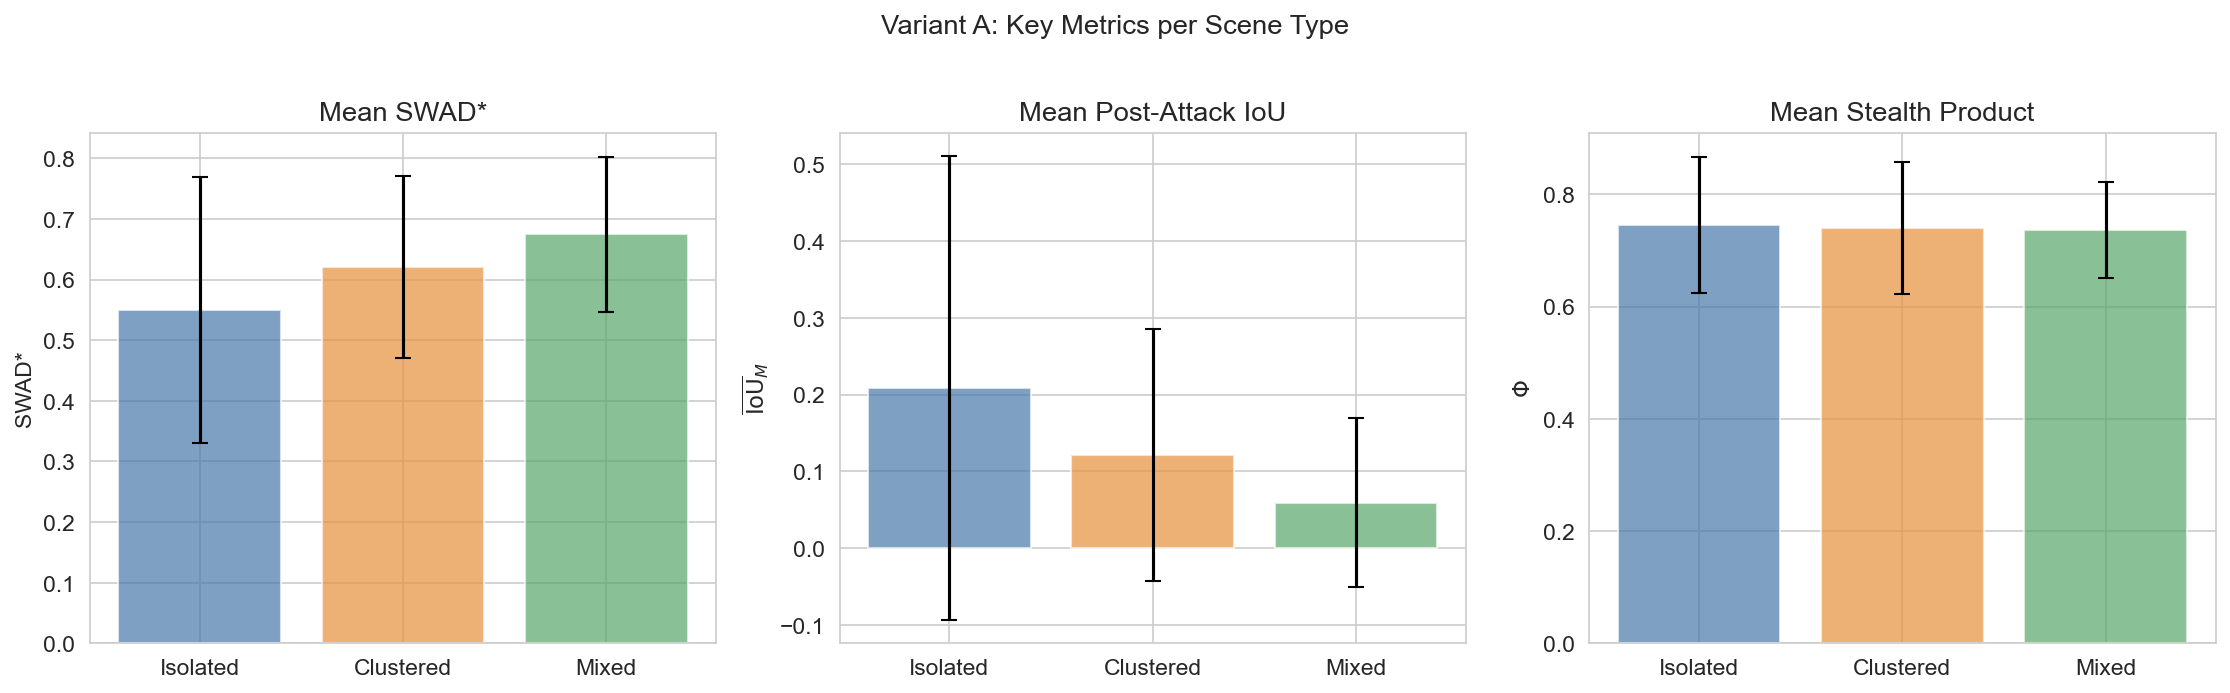

In [40]:
# ============================================================
# FIGURE 15: Grouped bar -- key metrics per scene type
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
for i, st in enumerate(SCENE_ORDER):
    vals = df_samples[df_samples.scene_type == st]['swad_star']
    ax.bar(i, vals.mean(), color=SCENE_COLORS[st], alpha=0.7,
           yerr=vals.std(), capsize=4, label=st)
ax.set_xticks(range(3))
ax.set_xticklabels(SCENE_ORDER)
ax.set_ylabel('SWAD*')
ax.set_title('Mean SWAD*')

ax = axes[1]
for i, st in enumerate(SCENE_ORDER):
    vals = df_samples[df_samples.scene_type == st]['swad_iou_m']
    ax.bar(i, vals.mean(), color=SCENE_COLORS[st], alpha=0.7,
           yerr=vals.std(), capsize=4)
ax.set_xticks(range(3))
ax.set_xticklabels(SCENE_ORDER)
ax.set_ylabel('$\\overline{\\mathrm{IoU}}_M$')
ax.set_title('Mean Post-Attack IoU')

ax = axes[2]
for i, st in enumerate(SCENE_ORDER):
    vals = df_samples[df_samples.scene_type == st]['swad_phi']
    ax.bar(i, vals.mean(), color=SCENE_COLORS[st], alpha=0.7,
           yerr=vals.std(), capsize=4)
ax.set_xticks(range(3))
ax.set_xticklabels(SCENE_ORDER)
ax.set_ylabel('$\\Phi$')
ax.set_title('Mean Stealth Product')

fig.suptitle('Variant A: Key Metrics per Scene Type', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_scene_type_summary.pdf'))
plt.show()

## Severity Distribution Analysis

In [41]:
print('=== Severity Distribution (SWAD*-Optimal) ===')
print(f'{"Modality":<10} {"Mean":>7} {"Std":>7} {"Median":>7} {"Min":>7} {"Max":>7}')
print('-' * 48)
for col, label in [('swad_img_scale', 'Image'), ('swad_txt_scale', 'Text')]:
    v = df_samples[col]
    print(f'{label:<10} {v.mean():>7.3f} {v.std():>7.3f} {v.median():>7.3f} '
          f'{v.min():>7.3f} {v.max():>7.3f}')

=== Severity Distribution (SWAD*-Optimal) ===
Modality      Mean     Std  Median     Min     Max
------------------------------------------------
Image        0.506   0.389   0.566   0.000   1.000
Text         0.562   0.263   0.604   0.003   1.000


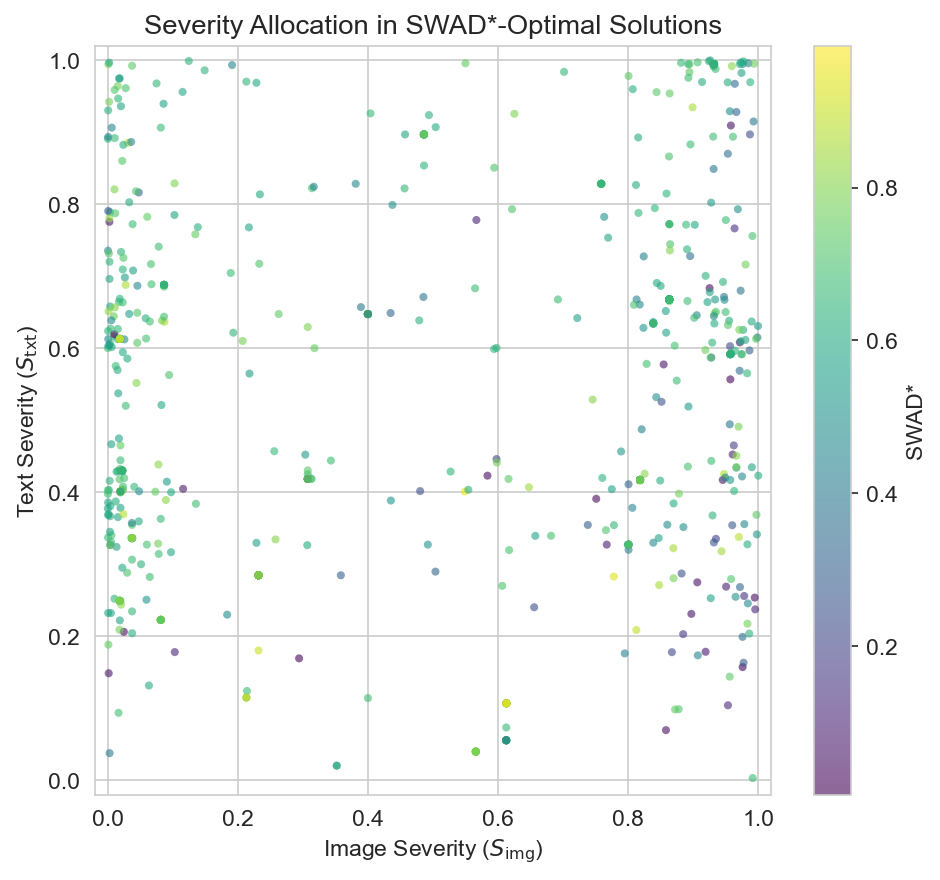

In [42]:
# ============================================================
# FIGURE 16: 2D scatter -- image severity vs. text severity (SWAD*-optimal)
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 6))

sc = ax.scatter(
    df_samples['swad_img_scale'],
    df_samples['swad_txt_scale'],
    c=df_samples['swad_star'],
    cmap='viridis', s=15, alpha=0.6, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='SWAD*')

ax.set_xlabel('Image Severity ($S_{\\mathrm{img}}$)')
ax.set_ylabel('Text Severity ($S_{\\mathrm{txt}}$)')
ax.set_title('Severity Allocation in SWAD*-Optimal Solutions')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_severity_scatter.pdf'))
plt.show()

In [43]:
print('\n=== Mean Severity When Selected as SWAD*-Optimal ===')
print(f'{"Attack":<22} {"Modality":<8} {"N":<5} {"Mean Sev":>9} {"Std Sev":>9}')
print('-' * 56)
for atk in IMAGE_ATTACKS:
    sub = df_samples[df_samples.swad_img_attack == atk]
    if len(sub) > 0:
        print(f'{IMG_NICE.get(atk, atk):<22} {"Image":<8} {len(sub):<5} '
              f'{sub.swad_img_scale.mean():>9.3f} {sub.swad_img_scale.std():>9.3f}')
for atk in TEXT_ATTACKS:
    sub = df_samples[df_samples.swad_txt_attack == atk]
    if len(sub) > 0:
        print(f'{TXT_NICE.get(atk, atk):<22} {"Text":<8} {len(sub):<5} '
              f'{sub.swad_txt_scale.mean():>9.3f} {sub.swad_txt_scale.std():>9.3f}')


=== Mean Severity When Selected as SWAD*-Optimal ===
Attack                 Modality N      Mean Sev   Std Sev
--------------------------------------------------------
JPEG Compression       Image    219       0.552     0.391
Pixelation             Image    220       0.604     0.389
Defocus Blur           Image    111       0.598     0.343
Motion Blur            Image    93        0.352     0.325
Gaussian Noise         Image    80        0.237     0.327
Fog Overlay            Image    27        0.286     0.342
Homophone              Text     345       0.607     0.269
Synonym                Text     69        0.565     0.259
Fragmentation          Text     3         0.297     0.123
Character Noise        Text     87        0.522     0.285
Lexical Saliency       Text     246       0.515     0.235


## Inference Efficiency

In [44]:
print('=== Inference Efficiency (SWAD*-Optimal Solutions) ===')
print(f'{"Scene Type":<18} {"Vis. Tokens":>12} {"Raw Tokens":>12} {"Runtime (s)":>12}')
print(f'{"":18} {"mean (std)":>12} {"mean (std)":>12} {"mean (std)":>12}')
print('-' * 60)
for st in SCENE_ORDER:
    sub = df_samples[df_samples.scene_type == st]
    tc = sub['swad_token_count']
    rtc = sub['swad_raw_tokens']
    rt = sub['swad_runtime']
    print(f'{st:<18} {tc.mean():>5.0f} ({tc.std():>4.0f}) '
          f'{rtc.mean():>5.0f} ({rtc.std():>4.0f}) '
          f'{rt.mean():>5.2f} ({rt.std():>4.2f})')

sub = df_samples
print('-' * 60)
tc = sub['swad_token_count']
rtc = sub['swad_raw_tokens']
rt = sub['swad_runtime']
print(f'{"Overall":<18} {tc.mean():>5.0f} ({tc.std():>4.0f}) '
      f'{rtc.mean():>5.0f} ({rtc.std():>4.0f}) '
      f'{rt.mean():>5.2f} ({rt.std():>4.2f})')

=== Inference Efficiency (SWAD*-Optimal Solutions) ===
Scene Type          Vis. Tokens   Raw Tokens  Runtime (s)
                     mean (std)   mean (std)   mean (std)
------------------------------------------------------------
Isolated              44 (  51)    54 (  51)  0.21 (0.18)
Clustered             76 ( 152)   152 ( 156)  0.53 (0.53)
Mixed                169 ( 243)   248 ( 230)  0.88 (0.83)
------------------------------------------------------------
Overall               96 ( 176)   151 ( 181)  0.54 (0.64)


## L2 vs. SWAD* Selection Comparison

In [45]:
print('=== L2 vs. SWAD* Selection Comparison ===')
print(f'{"Metric":<25} {"L2-Optimal":>12} {"SWAD*-Optimal":>14}')
print('-' * 55)

comparison_metrics = [
    ('Mean IoU_M',    'l2_iou_m',       'swad_iou_m'),
    ('Mean d_I',      'l2_img_dist',    'swad_img_dist'),
    ('Mean d_T',      'l2_txt_dist',    'swad_txt_dist'),
    ('Mean L2 dist',  'l2_l2_distance', 'swad_l2_distance'),
    ('Mean SWAD',     'l2_swad',        'swad_star'),
]
for label, l2_col, swad_col in comparison_metrics:
    l2_val = df_samples[l2_col].mean() if l2_col else '--'
    swad_val = df_samples[swad_col].mean() if swad_col else '--'
    l2_str = f'{l2_val:>12.4f}' if isinstance(l2_val, float) else f'{l2_val:>12}'
    swad_str = f'{swad_val:>14.4f}' if isinstance(swad_val, float) else f'{swad_val:>14}'
    print(f'{label:<25} {l2_str} {swad_str}')

=== L2 vs. SWAD* Selection Comparison ===
Metric                      L2-Optimal  SWAD*-Optimal
-------------------------------------------------------
Mean IoU_M                      0.1408         0.1295
Mean d_I                        0.0684         0.0666
Mean d_T                        0.1959         0.2051
Mean L2 dist                    0.3154         0.3180
Mean SWAD                       0.6107         0.6151


In [46]:
same_solution = (df_samples['swad_star_index'] == df_samples['l2_index']).sum()
print(f'\nL2 and SWAD* select the same Pareto solution: '
      f'{same_solution}/{len(df_samples)} ({100*same_solution/len(df_samples):.1f}%)')


L2 and SWAD* select the same Pareto solution: 660/750 (88.0%)


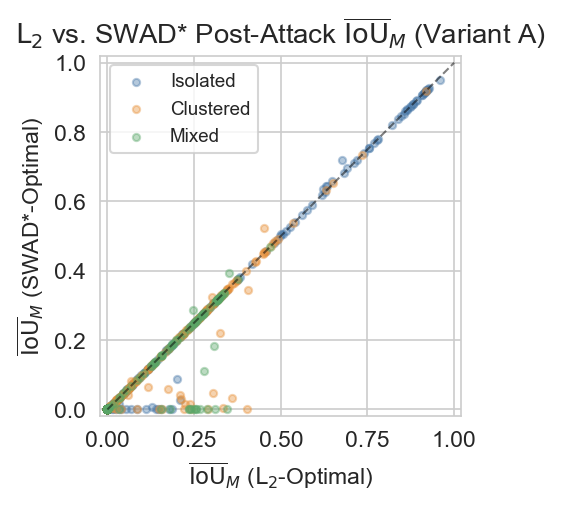

In [47]:
# ============================================================
# FIGURE 17: Paired scatter -- L2 IoU_M vs SWAD* IoU_M
# ============================================================

fig, ax = plt.subplots(figsize=(5.5, 3.5))

for st in SCENE_ORDER:
    sub = df_samples[df_samples.scene_type == st]
    ax.scatter(sub['l2_iou_m'], sub['swad_iou_m'], s=12, alpha=0.4,
              color=SCENE_COLORS[st], label=st)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('$\\overline{\\mathrm{IoU}}_M$ ($\\mathrm{L_2}$-Optimal)')
ax.set_ylabel('$\\overline{\\mathrm{IoU}}_M$ (SWAD*-Optimal)')
ax.set_title('$\\mathrm{L_2}$ vs. SWAD* Post-Attack $\\overline{\\mathrm{IoU}}_M$ (Variant A)')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_l2_vs_swad_iou.pdf'))
plt.show()

## Attack-Type Analysis

In [48]:
print('=== Image Attack Frequency (SWAD*-Optimal) ===')
img_freq = df_samples['swad_img_attack'].value_counts()
for atk in IMAGE_ATTACKS:
    n = img_freq.get(atk, 0)
    print(f'  {IMG_NICE.get(atk, atk):<20}: {n:>4} ({100*n/len(df_samples):>5.1f}%)')

print('\n=== Text Attack Frequency (SWAD*-Optimal) ===')
txt_freq = df_samples['swad_txt_attack'].value_counts()
for atk in TEXT_ATTACKS:
    n = txt_freq.get(atk, 0)
    print(f'  {TXT_NICE.get(atk, atk):<20}: {n:>4} ({100*n/len(df_samples):>5.1f}%)')

=== Image Attack Frequency (SWAD*-Optimal) ===
  JPEG Compression    :  219 ( 29.2%)
  Pixelation          :  220 ( 29.3%)
  Defocus Blur        :  111 ( 14.8%)
  Motion Blur         :   93 ( 12.4%)
  Gaussian Noise      :   80 ( 10.7%)
  Fog Overlay         :   27 (  3.6%)

=== Text Attack Frequency (SWAD*-Optimal) ===
  Homophone           :  345 ( 46.0%)
  Synonym             :   69 (  9.2%)
  Fragmentation       :    3 (  0.4%)
  Character Noise     :   87 ( 11.6%)
  Lexical Saliency    :  246 ( 32.8%)


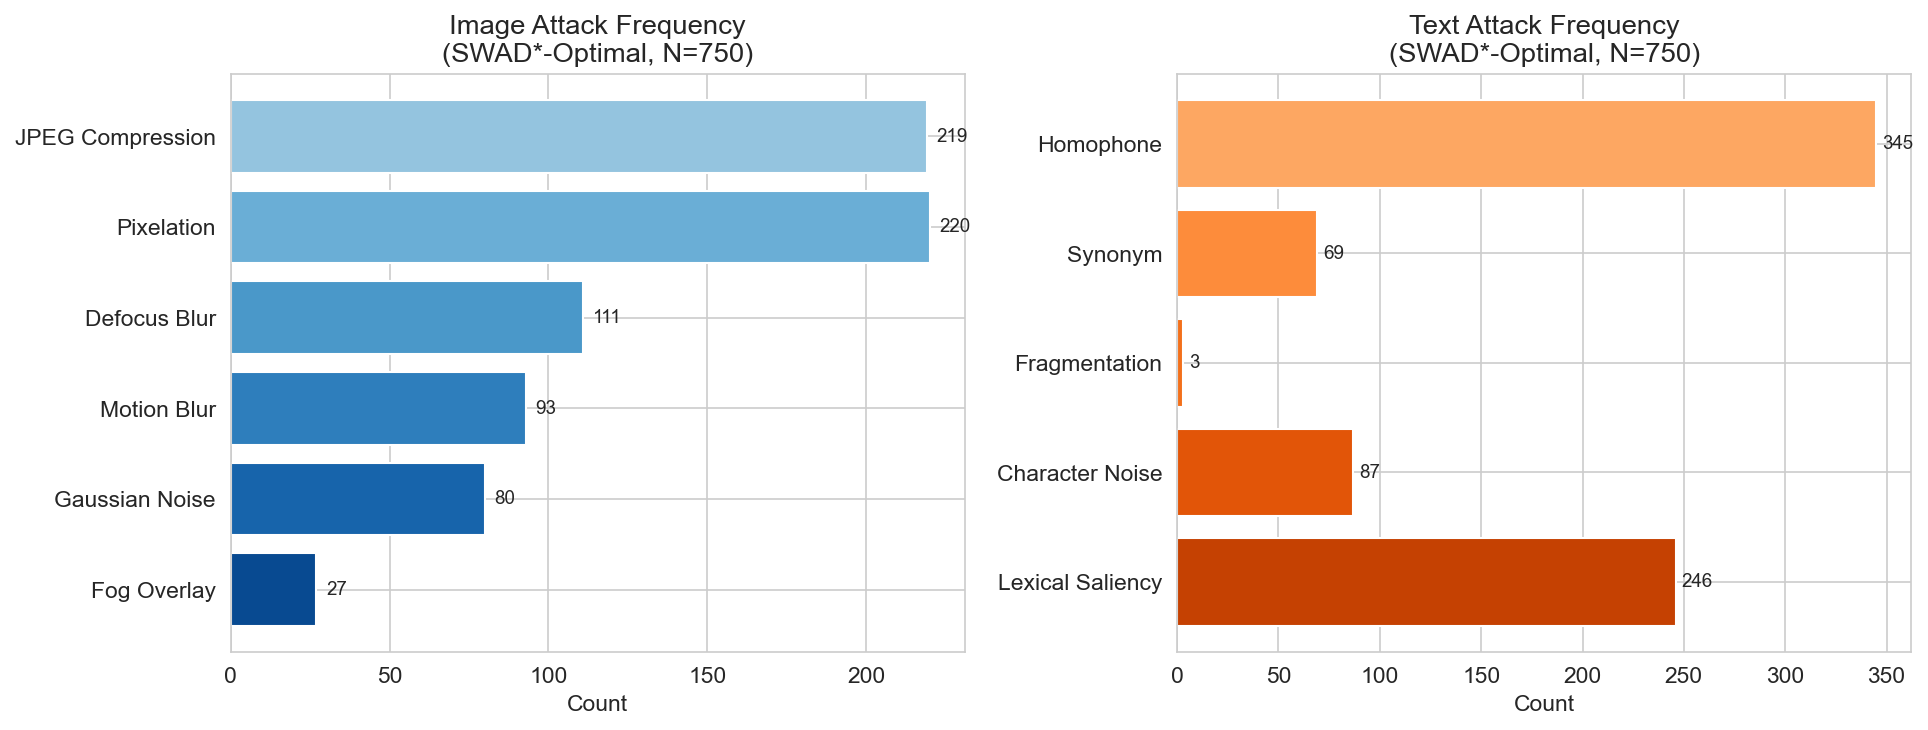

In [49]:
# ============================================================
# FIGURE 18: Bar charts -- attack frequency in SWAD*-optimal solutions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
img_counts = [img_freq.get(a, 0) for a in IMAGE_ATTACKS]
img_labels = [IMG_NICE[a] for a in IMAGE_ATTACKS]
colors_img = [plt.cm.Blues(0.4 + 0.1 * i) for i in range(len(IMAGE_ATTACKS))]
ax.barh(range(len(IMAGE_ATTACKS)), img_counts, color=colors_img, edgecolor='white')
ax.set_yticks(range(len(IMAGE_ATTACKS)))
ax.set_yticklabels(img_labels)
ax.set_xlabel('Count')
ax.set_title('Image Attack Frequency\n(SWAD*-Optimal, N=750)')
ax.invert_yaxis()
for i, c in enumerate(img_counts):
    ax.text(c + 3, i, str(c), va='center', fontsize=9)

ax = axes[1]
txt_counts = [txt_freq.get(a, 0) for a in TEXT_ATTACKS]
txt_labels = [TXT_NICE[a] for a in TEXT_ATTACKS]
colors_txt = [plt.cm.Oranges(0.4 + 0.1 * i) for i in range(len(TEXT_ATTACKS))]
ax.barh(range(len(TEXT_ATTACKS)), txt_counts, color=colors_txt, edgecolor='white')
ax.set_yticks(range(len(TEXT_ATTACKS)))
ax.set_yticklabels(txt_labels)
ax.set_xlabel('Count')
ax.set_title('Text Attack Frequency\n(SWAD*-Optimal, N=750)')
ax.invert_yaxis()
for i, c in enumerate(txt_counts):
    ax.text(c + 3, i, str(c), va='center', fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_attack_frequency_bars.pdf'))
plt.show()

## Comparison with Unimodal Ceiling

In [50]:
img_best_s4 = df_img_uni[
    (df_img_uni.severity == 4) & (df_img_uni.corruption.isin(IMAGE_ATTACKS))
].groupby(['scene_type', 'sample_id'])['IoU'].min().reset_index()
img_best_s4 = img_best_s4.rename(columns={'IoU': 'best_img_iou_s4'})

txt_best_s4 = df_txt_uni[
    (df_txt_uni.severity == 4) & (df_txt_uni.corruption.isin(TEXT_ATTACKS))
].groupby(['scene_type', 'sample_id'])['IoU'].min().reset_index()
txt_best_s4 = txt_best_s4.rename(columns={'IoU': 'best_txt_iou_s4'})

df_compare = df_samples[['scene_type', 'sample_id', 'baseline_iou', 'swad_iou_m', 'swad_star']].copy()
df_compare = df_compare.merge(img_best_s4, on=['scene_type', 'sample_id'], how='left')
df_compare = df_compare.merge(txt_best_s4, on=['scene_type', 'sample_id'], how='left')

df_compare['best_unimodal_s4'] = df_compare[['best_img_iou_s4', 'best_txt_iou_s4']].min(axis=1)

df_compare['mm_beats_uni'] = df_compare['swad_iou_m'] < df_compare['best_unimodal_s4']

print('=== Multimodal vs. Best Unimodal at S4 ===')
print(f'{"Scene Type":<18} {"MM < Uni":>9} {"Pct":>6} {"Mean MM IoU":>12} {"Mean Uni IoU":>13}')
print('-' * 62)
for st in SCENE_ORDER:
    sub = df_compare[df_compare.scene_type == st]
    n_beat = sub['mm_beats_uni'].sum()
    print(f'{st:<18} {n_beat:>5}/{len(sub):<3} {100*n_beat/len(sub):>5.1f}% '
          f'{sub.swad_iou_m.mean():>12.4f} {sub.best_unimodal_s4.mean():>13.4f}')

sub = df_compare
n_beat = sub['mm_beats_uni'].sum()
print('-' * 62)
print(f'{"Overall":<18} {n_beat:>5}/{len(sub):<3} {100*n_beat/len(sub):>5.1f}% '
      f'{sub.swad_iou_m.mean():>12.4f} {sub.best_unimodal_s4.mean():>13.4f}')

=== Multimodal vs. Best Unimodal at S4 ===
Scene Type          MM < Uni    Pct  Mean MM IoU  Mean Uni IoU
--------------------------------------------------------------
Isolated             190/250  76.0%       0.2085        0.5973
Clustered            177/250  70.8%       0.1209        0.3734
Mixed                129/250  51.6%       0.0593        0.2283
--------------------------------------------------------------
Overall              496/750  66.1%       0.1295        0.3997


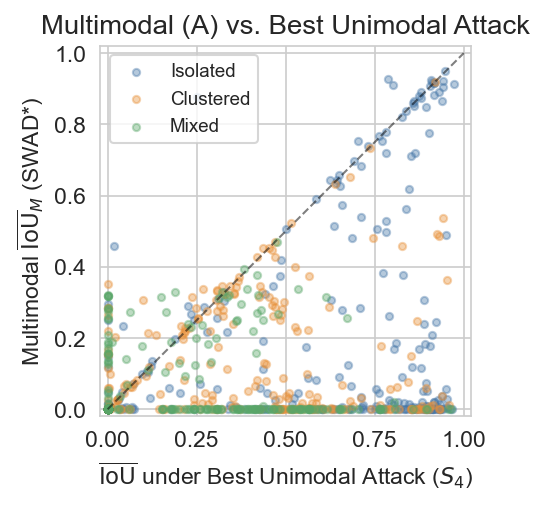

In [51]:
# ============================================================
# FIGURE 19: Scatter -- multimodal IoU vs best unimodal IoU
# ============================================================

fig, ax = plt.subplots(figsize=(4.0, 3.5))

for st in SCENE_ORDER:
    sub = df_compare[df_compare.scene_type == st]
    ax.scatter(sub['best_unimodal_s4'], sub['swad_iou_m'], s=12, alpha=0.4,
              color=SCENE_COLORS[st], label=st)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('$\\overline{\\mathrm{IoU}}$ under Best Unimodal Attack ($S_4$)')
ax.set_ylabel('Multimodal $\\overline{\\mathrm{IoU}}_M$ (SWAD*)')
ax.set_title('Multimodal (A) vs. Best Unimodal Attack')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_mm_vs_unimodal.pdf'))
plt.show()

## Summary Statistics

In [52]:
print('=' * 70)
print('VARIANT A -- KEY NUMBERS FOR EVALUATION CHAPTER')
print('=' * 70)

s = df_samples
print(f'\n--- Sample counts ---')
print(f'Total samples: {len(s)}')
print(f'Total Pareto solutions: {len(df_sols):,}')
print(f'Mean front size: {s.n_solutions.mean():.1f} (std={s.n_solutions.std():.1f})')

print(f'\n--- Detection Degradation (SWAD*) ---')
print(f'Mean IoU_M: {s.swad_iou_m.mean():.4f} (std={s.swad_iou_m.std():.4f})')
print(f'Median IoU_M: {s.swad_iou_m.median():.4f}')
print(f'Mean δ_M+: {s.swad_delta_m.mean():.4f}')
print(f'IoU_M = 0: {(s.swad_iou_m == 0).sum()}')
print(f'IoU_M < 0.1: {(s.swad_iou_m < 0.1).sum()}')
print(f'IoU_M <= 0.35: {(s.swad_iou_m <= 0.35).sum()}')

print(f'\n--- Stealth (SWAD*) ---')
print(f'Mean d_I: {s.swad_img_dist.mean():.4f} (std={s.swad_img_dist.std():.4f})')
print(f'Mean d_T: {s.swad_txt_dist.mean():.4f} (std={s.swad_txt_dist.std():.4f})')
print(f'Mean txt_sim: {s.swad_txt_sim.mean():.4f}')
print(f'Mean Φ: {s.swad_phi.mean():.4f} (std={s.swad_phi.std():.4f})')
print(f'Φ > 0.8: {(s.swad_phi > 0.8).sum()}')
print(f'Φ > 0.9: {(s.swad_phi > 0.9).sum()}')

print(f'\n--- SWAD* ---')
print(f'Mean: {s.swad_star.mean():.4f} (std={s.swad_star.std():.4f})')
print(f'Median: {s.swad_star.median():.4f}')
print(f'[Q25, Q75]: [{s.swad_star.quantile(0.25):.4f}, {s.swad_star.quantile(0.75):.4f}]')

print(f'\n--- Early Stopping ---')
n_es = s.early_stopped.sum()
print(f'Triggered: {n_es}/{len(s)} ({100*n_es/len(s):.1f}%)')
if n_es > 0:
    es_gens = s[s.early_stopped]['early_stop_gen']
    print(f'Mean generation: {es_gens.mean():.1f} (std={es_gens.std():.1f})')

print(f'\n--- Severity ---')
print(f'Mean img severity: {s.swad_img_scale.mean():.3f}')
print(f'Mean txt severity: {s.swad_txt_scale.mean():.3f}')

print(f'\n--- Unimodal Reference (ρ) ---')
if len(df_rho_valid) > 0:
    print(f'Valid samples: {len(df_rho_valid)} (excluded {len(df_rho) - len(df_rho_valid)} with δ_ref < 0.05)')
    print(f'Median ρ: {df_rho_valid.rho.median():.3f} [Q25={df_rho_valid.rho.quantile(0.25):.3f}, '
          f'Q75={df_rho_valid.rho.quantile(0.75):.3f}]')
    print(f'Mean ρ: {df_rho_valid.rho.mean():.3f}')
    print(f'ρ > 1: {(df_rho_valid.rho > 1).sum()}/{len(df_rho_valid)} '
          f'({100*(df_rho_valid.rho > 1).mean():.1f}%)')

print(f'\n--- Inference ---')
print(f'Mean visible tokens: {s.swad_token_count.mean():.0f} (std={s.swad_token_count.std():.0f})')
print(f'Mean runtime: {s.swad_runtime.mean():.2f}s (std={s.swad_runtime.std():.2f}s)')

VARIANT A -- KEY NUMBERS FOR EVALUATION CHAPTER

--- Sample counts ---
Total samples: 750
Total Pareto solutions: 13,354
Mean front size: 17.8 (std=10.0)

--- Detection Degradation (SWAD*) ---
Mean IoU_M: 0.1295 (std=0.2170)
Median IoU_M: 0.0067
Mean δ_M+: 0.8483
IoU_M = 0: 349
IoU_M < 0.1: 503
IoU_M <= 0.35: 668

--- Stealth (SWAD*) ---
Mean d_I: 0.0666 (std=0.0396)
Mean d_T: 0.2051 (std=0.1213)
Mean txt_sim: 0.7949
Mean Φ: 0.7407 (std=0.1092)
Φ > 0.8: 209
Φ > 0.9: 94

--- SWAD* ---
Mean: 0.6151 (std=0.1773)
Median: 0.6492
[Q25, Q75]: [0.5449, 0.7199]

--- Early Stopping ---
Triggered: 548/750 (73.1%)
Mean generation: 3.1 (std=3.2)

--- Severity ---
Mean img severity: 0.506
Mean txt severity: 0.562

--- Unimodal Reference (ρ) ---
Valid samples: 460 (excluded 290 with δ_ref < 0.05)
Median ρ: 2.188 [Q25=1.266, Q75=4.121]
Mean ρ: 3.583
ρ > 1: 421/460 (91.5%)

--- Inference ---
Mean visible tokens: 96 (std=176)
Mean runtime: 0.54s (std=0.64s)


In [53]:
print('\n=== PER-SCENE-TYPE SUMMARY TABLE (for LaTeX) ===\n')

for st in SCENE_ORDER + ['Overall']:
    sub = s[s.scene_type == st] if st != 'Overall' else s
    print(f'--- {st} (N={len(sub)}) ---')
    print(f'  Baseline IoU: {sub.baseline_iou.mean():.3f} ± {sub.baseline_iou.std():.3f}')
    print(f'  SWAD* IoU_M:  {sub.swad_iou_m.mean():.3f} ± {sub.swad_iou_m.std():.3f}')
    print(f'  SWAD*:        {sub.swad_star.mean():.4f} ± {sub.swad_star.std():.4f}')
    print(f'  d_I:          {sub.swad_img_dist.mean():.4f} ± {sub.swad_img_dist.std():.4f}')
    print(f'  d_T:          {sub.swad_txt_dist.mean():.4f} ± {sub.swad_txt_dist.std():.4f}')
    print(f'  Φ:            {sub.swad_phi.mean():.4f} ± {sub.swad_phi.std():.4f}')
    print(f'  δ_M+:         {sub.swad_delta_m.mean():.4f} ± {sub.swad_delta_m.std():.4f}')
    n_es = sub.early_stopped.sum()
    print(f'  Early-stop:   {n_es}/{len(sub)} ({100*n_es/len(sub):.1f}%)')
    print()


=== PER-SCENE-TYPE SUMMARY TABLE (for LaTeX) ===

--- Isolated (N=250) ---
  Baseline IoU: 0.923 ± 0.077
  SWAD* IoU_M:  0.208 ± 0.302
  SWAD*:        0.5501 ± 0.2195
  d_I:          0.0672 ± 0.0423
  d_T:          0.1976 ± 0.1424
  Φ:            0.7457 ± 0.1210
  δ_M+:         0.7740 ± 0.3223
  Early-stop:   123/250 (49.2%)

--- Clustered (N=250) ---
  Baseline IoU: 0.841 ± 0.126
  SWAD* IoU_M:  0.121 ± 0.164
  SWAD*:        0.6206 ± 0.1496
  d_I:          0.0627 ± 0.0346
  d_T:          0.2095 ± 0.1295
  Φ:            0.7399 ± 0.1173
  δ_M+:         0.8514 ± 0.1981
  Early-stop:   182/250 (72.8%)

--- Mixed (N=250) ---
  Baseline IoU: 0.782 ± 0.134
  SWAD* IoU_M:  0.059 ± 0.110
  SWAD*:        0.6744 ± 0.1275
  d_I:          0.0698 ± 0.0412
  d_T:          0.2083 ± 0.0843
  Φ:            0.7365 ± 0.0860
  δ_M+:         0.9194 ± 0.1494
  Early-stop:   243/250 (97.2%)

--- Overall (N=750) ---
  Baseline IoU: 0.849 ± 0.129
  SWAD* IoU_M:  0.130 ± 0.217
  SWAD*:        0.6151 ± 0.1773
 

In [54]:
print('\n=== Output files ===')
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f:55s} {sz:>8,} bytes')
print('\nDone!')


=== Output files ===
  fig_attack_frequency_bars.pdf                             23,319 bytes
  fig_degradation_violin.pdf                               109,451 bytes
  fig_degradation_violin_simple.pdf                         29,889 bytes
  fig_early_stop_scatter.pdf                                27,258 bytes
  fig_l2_vs_swad_iou.pdf                                    31,051 bytes
  fig_mm_vs_unimodal.pdf                                    33,237 bytes
  fig_pairing_frequency_heatmap.pdf                         25,642 bytes
  fig_pairing_swad_heatmap.pdf                              25,499 bytes
  fig_pareto_2d_projections.pdf                            499,954 bytes
  fig_pareto_examples.pdf                                   30,222 bytes
  fig_pareto_front_sizes.pdf                                17,937 bytes
  fig_phi_cdf.pdf                                           28,391 bytes
  fig_post_attack_iou_hist.pdf                              26,367 bytes
  fig_rho_heatmap.pdf        

In [55]:
extreme = df_rho_valid.nlargest(5, 'rho')[['scene_type','sample_id','img_attack','txt_attack',
    'img_scale','txt_scale','iou_0','delta_ref','delta_m_obs','rho']]
print(extreme.to_string())
low = df_rho_valid.nsmallest(5, 'rho')[['scene_type','sample_id','img_attack','txt_attack',
    'img_scale','txt_scale','iou_0','delta_ref','delta_m_obs','rho']]
print(low.to_string())

    scene_type  sample_id      img_attack       txt_attack  img_scale  txt_scale    iou_0  delta_ref  delta_m_obs        rho
478  Clustered        229        pixelate     ata_saliency   0.077336   0.328816  0.85286   0.053955      1.00000  18.533983
473  Clustered        224     motion_blur        homophone   0.231652   0.284744  0.89964   0.053203      0.97368  18.301146
159   Isolated        160     jpeg_filter  character_noise   0.001203   0.651516  0.93805   0.054880      1.00000  18.221639
264  Clustered         15    defocus_blur  character_noise   0.019448   0.249273  0.96509   0.052515      0.95394  18.165235
167   Isolated        168  gaussian_noise  character_noise   0.087051   0.636819  0.97788   0.055718      1.00000  17.947598
    scene_type  sample_id      img_attack    txt_attack  img_scale  txt_scale    iou_0  delta_ref  delta_m_obs       rho
514      Mixed         15        pixelate     homophone   0.863145   0.667899  0.58075   0.844501      0.45653  0.540591
200   Is

In [56]:
balanced = df_rho_valid[(df_rho_valid.img_scale.between(0.3,0.7)) & 
                         (df_rho_valid.txt_scale.between(0.3,0.7))]
concentrated = df_rho_valid[((df_rho_valid.img_scale > 0.8) & (df_rho_valid.txt_scale < 0.2)) |
                             ((df_rho_valid.txt_scale > 0.8) & (df_rho_valid.img_scale < 0.2))]
print(f'Balanced (both 0.3-0.7): n={len(balanced)}, mean ρ={balanced.rho.mean():.3f}, med={balanced.rho.median():.3f}')
print(f'Concentrated (one>0.8, other<0.2): n={len(concentrated)}, mean ρ={concentrated.rho.mean():.3f}, med={concentrated.rho.median():.3f}')

Balanced (both 0.3-0.7): n=35, mean ρ=3.027, med=2.341
Concentrated (one>0.8, other<0.2): n=24, mean ρ=3.109, med=1.854


In [57]:
moderate_cases = df_rho_valid[
    (df_rho_valid['rho'].between(2.5, 5.0)) &   # moderate excess, not extreme
    (df_rho_valid['delta_img'] > 0.08) &          # substantial image damage
    (df_rho_valid['delta_txt'] > 0.08)            # substantial text damage
].sort_values('rho', ascending=False)

cols = ['scene_type', 'sample_id', 'img_attack', 'txt_attack',
        'img_scale', 'txt_scale', 'iou_0', 'delta_img', 'delta_txt',
        'delta_ref', 'delta_m_obs', 'rho']
print(f'Found: {len(moderate_cases)}')
print(moderate_cases[cols].head(15).to_string())

Found: 12
    scene_type  sample_id    img_attack       txt_attack  img_scale  txt_scale    iou_0  delta_img  delta_txt  delta_ref  delta_m_obs       rho
536      Mixed         37   jpeg_filter        homophone   0.307337   0.418621  0.73123   0.130196   0.124307   0.238319      1.00000  4.196058
603      Mixed        104  defocus_blur  character_noise   0.565667   0.039875  0.62666   0.121620   0.168755   0.269851      1.00000  3.705751
361  Clustered        112      pixelate        homophone   0.989646   0.637224  0.95413   0.095972   0.202178   0.278746      0.98078  3.518539
660      Mixed        161  defocus_blur  character_noise   0.956810   0.591919  0.78373   0.248970   0.084226   0.312227      1.00000  3.202800
682      Mixed        183      pixelate     ata_saliency   0.037326   0.336470  0.59423   0.203221   0.149175   0.322080      1.00000  3.104818
553      Mixed         54   motion_blur  character_noise   0.934742   0.650756  0.81453   0.258498   0.087783   0.323589      

In [58]:
import difflib, re

SCENE_DIR_MAP = {v: k for k, v in SCENE_TYPE_MAP.items()}

def _norm(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'[\s\u200b\u200d]+', '', text)
    return text.lower()

def _label_match(pred, ref):
    p, g = _norm(pred), _norm(ref)
    if p == g: return True
    if sorted(p) == sorted(g): return True
    return difflib.SequenceMatcher(None, p, g).ratio() >= 0.75

def _extract_json_array(s):
    s = s.strip()
    a, b = s.find('['), s.rfind(']')
    if a == -1 or b == -1 or b < a: return []
    try: return json.loads(s[a:b+1])
    except: return []

def _extract_prompt_labels(prompt):
    m = re.search(r'objects "(.*?)"', prompt)
    if not m: return []
    return [_norm(x) for x in m.group(1).split(',')]

def _extract_prompt_labels_raw(prompt):
    """Same as above but no normalization -- preserves Cyrillic and invisibles."""
    m = re.search(r'objects "(.*?)"', prompt)
    if not m: return []
    return [x.strip() for x in m.group(1).split(',')]

def _is_accepted(pred_label, gt_bboxes, prompt_labels):
    for key in gt_bboxes:
        if _label_match(pred_label, key.split('_')[0]): return True
    for pl in prompt_labels:
        if _label_match(pred_label, pl): return True
    return False

N_EXAMPLES = 10
found = 0

for _, row in df_samples.iterrows():
    if found >= N_EXAMPLES: break

    pf_path = os.path.join(VARIANT_A_BASE_DIR, SCENE_DIR_MAP[row['scene_type']],
                           str(int(row['sample_id'])), 'pareto_front.json')
    with open(pf_path) as f:
        pf = json.load(f)

    swad_sol  = pf['solutions'][pf['swad_star_index']]
    vlm       = swad_sol['vlm_output']
    corrupt_p = vlm.get('adversarial_prompt') or vlm.get('corrupt_prompt', '')
    raw       = vlm.get('raw_response', '')
    gt        = pf['ground_truth_bboxes']

    all_preds          = _extract_json_array(raw)
    prompt_labels      = _extract_prompt_labels(corrupt_p)       # normalized, for matching
    prompt_labels_raw  = _extract_prompt_labels_raw(corrupt_p)   # raw, for display

    hallucinations = [
        p for p in all_preds
        if isinstance(p, dict) and 'bbox_2d' in p
        and not _is_accepted(p.get('label', ''), gt, prompt_labels)
    ]

    if not hallucinations: continue

    print(f"{'-'*65}")
    print(f"Sample {int(row['sample_id'])} ({row['scene_type']})  "
          f"txt_attack={row['swad_txt_attack']}  S={row['swad_txt_scale']:.3f}  "
          f"IoU_M={row['swad_iou_m']:.4f}")
    print(f"  GT label        : {[k.split('_')[0] for k in gt]}")
    for raw_lbl, norm_lbl in zip(prompt_labels_raw, prompt_labels):
        corrupted_normalized = ''.join(f'[{c}]' if ord(c) > 127 else c for c in norm_lbl)
        print(f"  Corrupted label : {raw_lbl!r}  ->  (normalized) {norm_lbl!r}  ->  (corrupted normalized) '{corrupted_normalized}'")
    for p in hallucinations:
        vlm_lbl = p.get('label', '')
        print(f"  Hallucination   : {vlm_lbl!r}  ->  (normalized) {_norm(vlm_lbl)!r}")
        for raw_lbl in prompt_labels_raw:
            def fmt_codepoints(s):
                parts = []
                for c in s:
                    token = f'{c}=U+{ord(c):04X}'
                    parts.append(f'[{token}]' if ord(c) > 127 else token)
                return ' '.join(parts)
            print(f"  Label codepoints   : {fmt_codepoints(raw_lbl)}")
            print(f"  Response codepoints: {fmt_codepoints(vlm_lbl)}")
    print()

    found += 1

-----------------------------------------------------------------
Sample 16 (Isolated)  txt_attack=character_noise  S=0.886  IoU_M=0.0000
  GT label        : ['domestic cat']
  Corrupted label : 'd\u200bо\u200dm\u200bеs\u200bt\u200bi\u200bс c\u200dа\u200dt\u200b'  ->  (normalized) 'dоmеstiсcаt'  ->  (corrupted normalized) 'd[о]m[е]sti[с]c[а]t'
  Hallucination   : 'd\u200bо\u200dм\u200bе\u200bс\u200bт\u200bи\u200bс\u200bс\u200bк\u200bо\u200bе\u200b к\u200bа\u200bт\u200bь\u200bе'  ->  (normalized) 'dоместисскоекатье'
  Label codepoints   : d=U+0064 [​=U+200B] [о=U+043E] [‍=U+200D] m=U+006D [​=U+200B] [е=U+0435] s=U+0073 [​=U+200B] t=U+0074 [​=U+200B] i=U+0069 [​=U+200B] [с=U+0441]  =U+0020 c=U+0063 [‍=U+200D] [а=U+0430] [‍=U+200D] t=U+0074 [​=U+200B]
  Response codepoints: d=U+0064 [​=U+200B] [о=U+043E] [‍=U+200D] [м=U+043C] [​=U+200B] [е=U+0435] [​=U+200B] [с=U+0441] [​=U+200B] [т=U+0442] [​=U+200B] [и=U+0438] [​=U+200B] [с=U+0441] [​=U+200B] [с=U+0441] [​=U+200B] [к=U+043A] [​=U+200B] 

## Cross-Lingual Script-Switching Analysis

In [59]:
QWEN_SCALE_FACTOR = 1000
import unicodedata


_CYRILLIC_HOMOGLYPHS = set('асеіорхуАВСЕНІКМОРТХ')

_CYRILLIC_RANGE = range(0x0400, 0x0500)  # Basic Cyrillic block
_LATIN_EXT_A    = range(0x0100, 0x0180)  # Latin Extended-A (ā, ē, etc.)
_LATIN_EXT_B    = range(0x0180, 0x0250)

def _count_script_chars(text):
    """Classify each character in *text* by Unicode block.
    Returns dict: {script_name: count}."""
    counts = {'latin_basic': 0, 'latin_extended': 0, 'cyrillic': 0,
              'digit': 0, 'space_zw': 0, 'other': 0}
    for ch in text:
        cp = ord(ch)
        if ch.isascii() and ch.isalpha():
            counts['latin_basic'] += 1
        elif cp in _CYRILLIC_RANGE:
            counts['cyrillic'] += 1
        elif cp in _LATIN_EXT_A or cp in _LATIN_EXT_B:
            counts['latin_extended'] += 1
        elif ch.isdigit():
            counts['digit'] += 1
        elif ch in (' ', '\u200b', '\u200d', '\t', '\n'):
            counts['space_zw'] += 1
        else:
            counts['other'] += 1
    return counts

def classify_label_script(label_text):
    """Classify a VLM-predicted label into script categories.

    Returns one of:
      'latin_only'     -- all alphabetic chars are basic Latin
      'cyrillic_full'  -- all alphabetic chars are Cyrillic
      'cyrillic_mixed' -- mix of Latin + Cyrillic alphabetic chars
      'diacritical'    -- contains Latin Extended but no Cyrillic
      'empty'          -- no alphabetic content
    """
    if not label_text or not isinstance(label_text, str):
        return 'empty'
    c = _count_script_chars(label_text)
    alpha_total = c['latin_basic'] + c['cyrillic'] + c['latin_extended']
    if alpha_total == 0:
        return 'empty'
    if c['cyrillic'] > 0 and c['latin_basic'] == 0 and c['latin_extended'] == 0:
        return 'cyrillic_full'
    if c['cyrillic'] > 0:
        return 'cyrillic_mixed'
    if c['latin_extended'] > 0:
        return 'diacritical'
    return 'latin_only'

def has_cyrillic(text):
    """Quick check: does the string contain any Cyrillic codepoint?"""
    if not text:
        return False
    return any(ord(c) in _CYRILLIC_RANGE for c in text)

def cyrillic_fraction(text):
    """Fraction of alphabetic characters that are Cyrillic."""
    if not text:
        return 0.0
    c = _count_script_chars(text)
    alpha = c['latin_basic'] + c['cyrillic'] + c['latin_extended']
    if alpha == 0:
        return 0.0
    return c['cyrillic'] / alpha

assert classify_label_script('monkey') == 'latin_only'
assert classify_label_script('mонкеу') == 'cyrillic_mixed'
assert classify_label_script('елепант') == 'cyrillic_full'
assert classify_label_script('snākē') == 'diacritical'
print('Script classification self-tests passed')


Script classification self-tests passed


In [60]:
# Scan every Pareto solution (not just SWAD*) for cross-lingual labels

va_script_rows = []  # one row per (sample, solution, prediction)

for _, row in df_samples.iterrows():
    sid  = int(row['sample_id'])
    st   = row['scene_type']
    pf_path = os.path.join(VARIANT_A_BASE_DIR,
                           SCENE_DIR_MAP[st], str(sid), 'pareto_front.json')
    with open(pf_path) as f:
        pf = json.load(f)

    gt         = pf['ground_truth_bboxes']
    gt_labels  = [k.split('_')[0] for k in gt]
    swad_idx   = pf['swad_star_index']

    for sol in pf['solutions']:
        vlm     = sol['vlm_output']
        raw     = vlm.get('raw_response', '')
        prompt  = vlm.get('adversarial_prompt') or vlm.get('corrupt_prompt', '')
        preds   = _extract_json_array(raw)
        p_labels = _extract_prompt_labels(prompt)

        txt_atk = sol['genome']['txt_attack']
        txt_s   = sol['genome']['txt_scale']
        img_atk = sol['genome']['img_attack']
        img_s   = sol['genome']['img_scale']
        iou_m   = sol['objectives']['iou']
        is_swad = (sol['index'] == swad_idx)

        for pred in preds:
            if not isinstance(pred, dict) or 'bbox_2d' not in pred:
                continue
            lbl = pred.get('label', '')
            script = classify_label_script(lbl)
            accepted = _is_accepted(lbl, gt, p_labels)

            va_script_rows.append({
                'sample_id':  sid,
                'scene_type': st,
                'sol_index':  sol['index'],
                'is_swad_star': is_swad,
                'txt_attack': txt_atk,
                'txt_scale':  txt_s,
                'img_attack': img_atk,
                'img_scale':  img_s,
                'iou_m':      iou_m,
                'pred_label': lbl,
                'script_class': script,
                'label_accepted': accepted,
                'cyrillic_frac': cyrillic_fraction(lbl),
                'bbox': pred['bbox_2d'],
                'setting': 'multimodal',
            })

df_va_preds = pd.DataFrame(va_script_rows)
print(f'Variant A: {len(df_va_preds):,} predictions across '
      f'{df_va_preds.sample_id.nunique()} samples')
print(f'\nScript class distribution (all Pareto predictions):')
print(df_va_preds['script_class'].value_counts().to_string())


Variant A: 26,260 predictions across 250 samples

Script class distribution (all Pareto predictions):
script_class
latin_only        24914
cyrillic_mixed     1281
cyrillic_full        62
diacritical           3


In [61]:
# =======================================================================
# Load raw VLM responses from unimodal text corruption JSONs
# =======================================================================

UNIMODAL_BASE = 'unimodal/text_corruptions'
SCALE_MAP_INV = {0: 0.0, 1: 0.25, 2: 0.5, 3: 0.75, 4: 1.0}

uni_script_rows = []

for rel_dir, scene_label in SCENE_TYPE_MAP.items():
    group_dir = os.path.join(UNIMODAL_BASE, rel_dir)
    if not os.path.isdir(group_dir):
        continue

    folder_ids = sorted(
        [d for d in os.listdir(group_dir)
         if os.path.isdir(os.path.join(group_dir, d))],
        key=lambda x: int(x)
    )

    for fid in folder_ids:
        sample_dir = os.path.join(group_dir, fid)
        sid = int(fid)

        for scale_idx in range(5):
            json_path = os.path.join(sample_dir, f'scale_{scale_idx}_TEXT.json')
            if not os.path.isfile(json_path):
                continue

            with open(json_path) as f:
                data = json.load(f)

            gt_bboxes = data.get('ground_truth_bboxes', {})
            gt_labels = [k.split('_')[0] for k in gt_bboxes]
            sev_float = SCALE_MAP_INV[scale_idx]

            for attack_name, attack_data in data.get('corruptions', {}).items():
                if attack_name not in TEXT_ATTACKS:
                    continue  # skip instruction-level

                raw_response = attack_data.get('result', '')
                corrupt_prompt = attack_data.get('prompt', '')
                iou_val = attack_data.get('IoU', 0.0)

                preds = _extract_json_array(raw_response)
                p_labels = _extract_prompt_labels(corrupt_prompt)

                for pred in preds:
                    if not isinstance(pred, dict) or 'bbox_2d' not in pred:
                        continue
                    lbl = pred.get('label', '')
                    script = classify_label_script(lbl)
                    accepted = _is_accepted(lbl, gt_bboxes, p_labels)

                    uni_script_rows.append({
                        'sample_id':  sid,
                        'scene_type': scene_label,
                        'txt_attack': attack_name,
                        'txt_scale':  sev_float,
                        'severity_idx': scale_idx,
                        'iou_m':      iou_val,
                        'pred_label': lbl,
                        'script_class': script,
                        'label_accepted': accepted,
                        'cyrillic_frac': cyrillic_fraction(lbl),
                        'bbox': pred['bbox_2d'],
                        'setting': 'unimodal',
                    })

df_uni_preds = pd.DataFrame(uni_script_rows)
print(f'Unimodal: {len(df_uni_preds):,} predictions across '
      f'{df_uni_preds.sample_id.nunique()} samples, '
      f'{df_uni_preds.txt_attack.nunique()} attacks')
print(f'\nScript class distribution (all unimodal predictions):')
print(df_uni_preds['script_class'].value_counts().to_string())

# Build per-sample dimension lookup from unimodal JSON original_dims
_dims_lookup = {}
for rel_dir, scene_label in SCENE_TYPE_MAP.items():
    group_dir = os.path.join(UNIMODAL_BASE, rel_dir)
    if not os.path.isdir(group_dir):
        continue
    for fid in os.listdir(group_dir):
        fpath = os.path.join(group_dir, fid)
        if not os.path.isdir(fpath):
            continue
        sid = int(fid)
        # Load dimensions from the first available scale JSON
        for si in range(5):
            jp = os.path.join(fpath, f'scale_{si}_TEXT.json')
            if os.path.isfile(jp):
                with open(jp) as _f:
                    _d = json.load(_f)
                if 'original_dims' in _d:
                    _dims_lookup[(scene_label, sid)] = tuple(_d['original_dims'])
                break
print(f'Dimension lookup: {len(_dims_lookup)} samples')


Unimodal: 50,154 predictions across 250 samples, 5 attacks

Script class distribution (all unimodal predictions):
script_class
latin_only        43553
cyrillic_mixed     6207
cyrillic_full       389
diacritical           5
Dimension lookup: 750 samples


In [62]:
# Compare cross-lingual label rates between multimodal and unimodal

def _script_switch_rate(df):
    """Fraction of predictions that are cyrillic_full, cyrillic_mixed, or diacritical."""
    n = len(df)
    if n == 0:
        return 0.0, 0, 0
    shifted = df['script_class'].isin(['cyrillic_full', 'cyrillic_mixed', 'diacritical']).sum()
    return shifted / n, shifted, n

print('=' * 80)
print('  CROSS-LINGUAL LABEL SHIFT RATES -- BY ATTACK TYPE')
print('  (fraction of VLM predictions containing non-Latin characters)')
print('=' * 80)

print(f'\n{"Attack":<20} {"Setting":<14} {"Shifted":>8} {"Total":>8} {"Rate":>8}')
print('-' * 60)

for atk in TEXT_ATTACKS:
    for setting, df in [('multimodal', df_va_preds), ('unimodal', df_uni_preds)]:
        sub = df[df.txt_attack == atk]
        rate, shifted, total = _script_switch_rate(sub)
        print(f'{TXT_NICE.get(atk, atk):<20} {setting:<14} {shifted:>8} {total:>8} {rate:>8.4f}')
    print()


  CROSS-LINGUAL LABEL SHIFT RATES -- BY ATTACK TYPE
  (fraction of VLM predictions containing non-Latin characters)

Attack               Setting         Shifted    Total     Rate
------------------------------------------------------------
Homophone            multimodal            0    10688   0.0000
Homophone            unimodal              0     9416   0.0000

Synonym              multimodal            0     3723   0.0000
Synonym              unimodal              0    10347   0.0000

Fragmentation        multimodal            0      192   0.0000
Fragmentation        unimodal              0    10632   0.0000

Character Noise      multimodal         1346     2628   0.5122
Character Noise      unimodal           6601    10127   0.6518

Lexical Saliency     multimodal            0     9029   0.0000
Lexical Saliency     unimodal              0     9632   0.0000



In [63]:
# =======================================================================

print('=' * 80)
print('  CHARACTER NOISE -- SCRIPT-SWITCHING RATE BY SEVERITY')
print('  Multimodal (Variant A) vs Unimodal (clean image)')
print('=' * 80)

# Unimodal: exact discrete severity levels
uni_cn = df_uni_preds[df_uni_preds.txt_attack == 'character_noise']

# Variant A: bin continuous severity into nearest discrete level
va_cn = df_va_preds[df_va_preds.txt_attack == 'character_noise'].copy()
va_cn['sev_bin'] = va_cn['txt_scale'].apply(
    lambda s: min(range(5), key=lambda i: abs(s - SCALE_MAP_INV[i]))
)

print(f'\n{"Sev":<6} {"Sev Float":<10} │ {"Uni Shifted":>12} {"Uni Total":>10} {"Uni Rate":>10}'
      f' │ {"MM Shifted":>11} {"MM Total":>9} {"MM Rate":>9}')
print('-' * 95)

for sev_idx in range(5):
    sev_f = SCALE_MAP_INV[sev_idx]

    # Unimodal
    u_sub = uni_cn[uni_cn.severity_idx == sev_idx]
    u_rate, u_shift, u_tot = _script_switch_rate(u_sub)

    # Multimodal (binned)
    m_sub = va_cn[va_cn.sev_bin == sev_idx]
    m_rate, m_shift, m_tot = _script_switch_rate(m_sub)

    print(f'  S{sev_idx}   {sev_f:<10.2f} │ {u_shift:>12} {u_tot:>10} {u_rate:>10.4f}'
          f' │ {m_shift:>11} {m_tot:>9} {m_rate:>9.4f}')


  CHARACTER NOISE -- SCRIPT-SWITCHING RATE BY SEVERITY
  Multimodal (Variant A) vs Unimodal (clean image)

Sev    Sev Float  │  Uni Shifted  Uni Total   Uni Rate │  MM Shifted  MM Total   MM Rate
-----------------------------------------------------------------------------------------------
  S0   0.00       │          461       2135     0.2159 │         201       699    0.2876
  S1   0.25       │         1103       2090     0.5278 │         435       979    0.4443
  S2   0.50       │         1497       2018     0.7418 │         359       532    0.6748
  S3   0.75       │         1719       1979     0.8686 │         231       292    0.7911
  S4   1.00       │         1821       1905     0.9559 │         120       126    0.9524


In [64]:

print('\n' + '=' * 80)
print('  CHARACTER NOISE -- SCRIPT CLASS BREAKDOWN')
print('=' * 80)

for setting_name, df_src in [('Unimodal', uni_cn), ('Multimodal (Variant A)', va_cn)]:
    print(f'\n  {setting_name}:')
    vc = df_src['script_class'].value_counts()
    total = len(df_src)
    for cls in ['latin_only', 'cyrillic_mixed', 'cyrillic_full', 'diacritical', 'empty']:
        n = vc.get(cls, 0)
        pct = 100 * n / total if total > 0 else 0
        print(f'    {cls:<20s} {n:>8,}  ({pct:>5.1f}%)')
    print(f'    {"TOTAL":<20s} {total:>8,}')



  CHARACTER NOISE -- SCRIPT CLASS BREAKDOWN

  Unimodal:
    latin_only              3,526  ( 34.8%)
    cyrillic_mixed          6,207  ( 61.3%)
    cyrillic_full             389  (  3.8%)
    diacritical                 5  (  0.0%)
    empty                       0  (  0.0%)
    TOTAL                  10,127

  Multimodal (Variant A):
    latin_only              1,282  ( 48.8%)
    cyrillic_mixed          1,281  ( 48.7%)
    cyrillic_full              62  (  2.4%)
    diacritical                 3  (  0.1%)
    empty                       0  (  0.0%)
    TOTAL                   2,628


In [65]:
# For predictions with cross-lingual labels, compute the IoU *ignoring*
# label matching to determine if the model actually detected the object.

def _bbox_only_iou(pred_bbox, gt_bboxes, orig_w, orig_h):
    """Compute max IoU of a prediction bbox against ALL GT boxes, ignoring labels."""
    best = 0.0
    scaled = [
        pred_bbox[0] * orig_w / QWEN_SCALE_FACTOR,
        pred_bbox[1] * orig_h / QWEN_SCALE_FACTOR,
        pred_bbox[2] * orig_w / QWEN_SCALE_FACTOR,
        pred_bbox[3] * orig_h / QWEN_SCALE_FACTOR,
    ]
    for key, box in gt_bboxes.items():
        gt_box = [box['xmin'], box['ymin'], box['xmax'], box['ymax']]
        xa = max(scaled[0], gt_box[0])
        ya = max(scaled[1], gt_box[1])
        xb = min(scaled[2], gt_box[2])
        yb = min(scaled[3], gt_box[3])
        inter = max(0, xb - xa) * max(0, yb - ya)
        area_a = max(0, scaled[2] - scaled[0]) * max(0, scaled[3] - scaled[1])
        area_b = max(0, gt_box[2] - gt_box[0]) * max(0, gt_box[3] - gt_box[1])
        denom = area_a + area_b - inter
        iou = inter / denom if denom > 0 else 0.0
        best = max(best, iou)
    return best


print('=' * 80)
print('  BBOX-ONLY IoU -- SCRIPT-SWITCHED vs LABEL-ACCEPTED PREDICTIONS')
print('  (Variant A, SWAD*-optimal solutions only)')
print('=' * 80)

swad_preds = df_va_preds[df_va_preds.is_swad_star].copy()

_gt_cache = {}
def _get_gt(scene_type, sample_id):
    key = (scene_type, sample_id)
    if key not in _gt_cache:
        pf_path = os.path.join(VARIANT_A_BASE_DIR,
                               SCENE_DIR_MAP[scene_type], str(sample_id),
                               'pareto_front.json')
        with open(pf_path) as f:
            pf = json.load(f)
        _gt_cache[key] = pf['ground_truth_bboxes']
    return _gt_cache[key]

bbox_ious = []
skipped_dims = 0
for _, pred_row in swad_preds.iterrows():
    st, sid = pred_row['scene_type'], pred_row['sample_id']
    gt = _get_gt(st, sid)
    dims = _dims_lookup.get((st, sid))
    if dims is None:
        bbox_ious.append(np.nan)
        skipped_dims += 1
        continue
    ow, oh = dims
    bbox_iou = _bbox_only_iou(pred_row['bbox'], gt, ow, oh)
    bbox_ious.append(bbox_iou)

swad_preds['bbox_only_iou'] = bbox_ious
if skipped_dims > 0:
    print(f'  Warning: {skipped_dims} predictions skipped (missing image dimensions)')

shifted = swad_preds[swad_preds.script_class.isin(
    ['cyrillic_full', 'cyrillic_mixed', 'diacritical'])]
accepted = swad_preds[swad_preds.label_accepted]
rejected_latin = swad_preds[
    ~swad_preds.label_accepted &
    (swad_preds.script_class == 'latin_only')
]

print(f'\n{"Category":<30} {"N":>6} {"Mean BBox IoU":>14} {"Median":>8} '
      f'{"BBox>0.5":>9} {"BBox>0.3":>9}')
print('-' * 80)
for label, sub in [('Script-switched', shifted),
                    ('Latin, accepted', accepted),
                    ('Latin, rejected', rejected_latin)]:
    n = len(sub)
    valid = sub['bbox_only_iou'].dropna()
    if len(valid) > 0:
        m = valid.mean()
        med = valid.median()
        gt5 = (valid > 0.5).sum()
        gt3 = (valid > 0.3).sum()
        print(f'{label:<30} {n:>6} {m:>14.4f} {med:>8.4f} '
              f'{gt5:>9} {gt3:>9}')
    else:
        print(f'{label:<30} {n:>6} {"--":>14}')


  BBOX-ONLY IoU -- SCRIPT-SWITCHED vs LABEL-ACCEPTED PREDICTIONS
  (Variant A, SWAD*-optimal solutions only)

Category                            N  Mean BBox IoU   Median  BBox>0.5  BBox>0.3
--------------------------------------------------------------------------------
Script-switched                   124         0.6945   0.8302        94       108
Latin, accepted                   610         0.3117   0.1778       178       245
Latin, rejected                   176         0.7771   0.9079       154       161


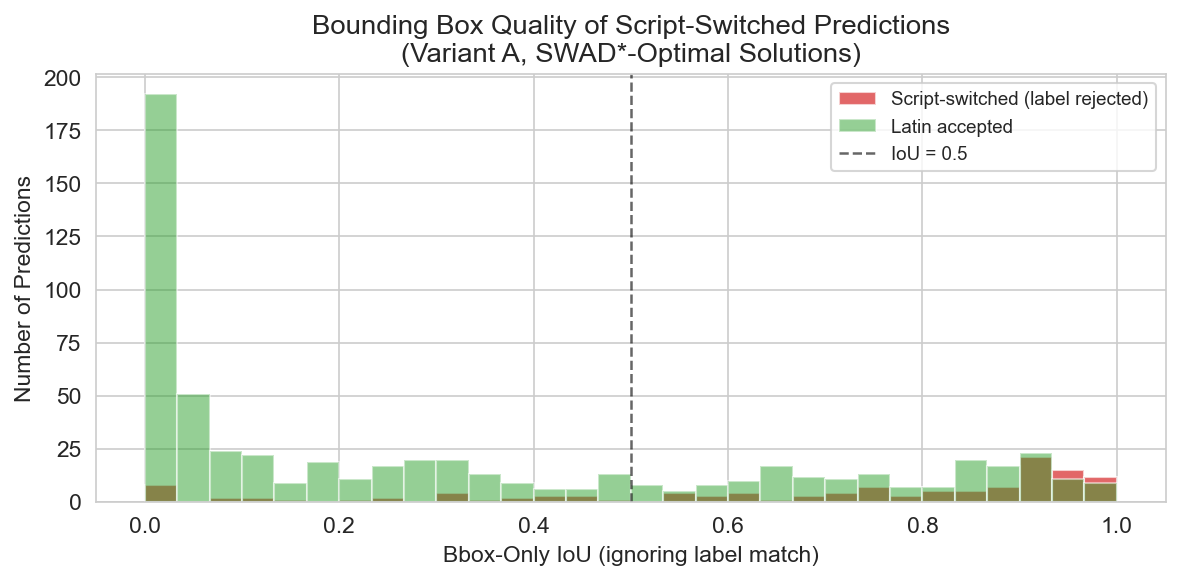


Key finding: 94/124 (75.8%) of script-switched predictions have bbox IoU > 0.5
These are correct detections scored as IoU=0 due to label mismatch.


In [66]:

if len(shifted) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    bins = np.linspace(0, 1, 31)

    ax.hist(shifted['bbox_only_iou'], bins=bins, alpha=0.7,
            color='#d62728', edgecolor='white', label='Script-switched (label rejected)')
    if len(accepted) > 0:
        ax.hist(accepted['bbox_only_iou'], bins=bins, alpha=0.5,
                color='#2ca02c', edgecolor='white', label='Latin accepted')

    ax.axvline(0.5, color='black', ls='--', lw=1.2, alpha=0.6, label='IoU = 0.5')
    ax.set_xlabel('Bbox-Only IoU (ignoring label match)')
    ax.set_ylabel('Number of Predictions')
    ax.set_title('Bounding Box Quality of Script-Switched Predictions\n'
                 '(Variant A, SWAD*-Optimal Solutions)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'fig_script_switch_bbox_iou.pdf'))
    plt.show()

    print(f'\nKey finding: {(shifted.bbox_only_iou > 0.5).sum()}/{len(shifted)} '
          f'({100*(shifted.bbox_only_iou > 0.5).mean():.1f}%) of script-switched '
          f'predictions have bbox IoU > 0.5')
    print(f'These are correct detections scored as IoU=0 due to label mismatch.')


In [67]:
# =======================================================================

print('=' * 80)
print('  ONSET ANALYSIS -- MINIMUM txt_scale PRODUCING SCRIPT-SWITCHING')
print('=' * 80)

# Variant A: all Pareto solutions with character_noise
va_cn_shifted = df_va_preds[
    (df_va_preds.txt_attack == 'character_noise') &
    df_va_preds.script_class.isin(['cyrillic_full', 'cyrillic_mixed', 'diacritical'])
]

if len(va_cn_shifted) > 0:
    onset_per_sample = va_cn_shifted.groupby(
        ['sample_id', 'scene_type']
    )['txt_scale'].min().reset_index()
    onset_per_sample.columns = ['sample_id', 'scene_type', 'min_txt_scale']

    print(f'\nVariant A -- character_noise onset (per sample):')
    print(f'  Samples affected:  {len(onset_per_sample)}/{df_samples.sample_id.nunique()}')
    print(f'  Mean onset scale:  {onset_per_sample.min_txt_scale.mean():.3f}')
    print(f'  Median:            {onset_per_sample.min_txt_scale.median():.3f}')
    print(f'  Min:               {onset_per_sample.min_txt_scale.min():.3f}')
    print(f'  Q25:               {onset_per_sample.min_txt_scale.quantile(0.25):.3f}')
    print(f'  Q75:               {onset_per_sample.min_txt_scale.quantile(0.75):.3f}')

    # Per scene type
    print(f'\n  Per scene type:')
    for st in SCENE_ORDER:
        sub = onset_per_sample[onset_per_sample.scene_type == st]
        if len(sub) > 0:
            print(f'    {st:<12} n={len(sub):>3}  '
                  f'mean={sub.min_txt_scale.mean():.3f}  '
                  f'median={sub.min_txt_scale.median():.3f}')
else:
    print('\n  No script-switching detected in Variant A character_noise solutions.')

# Unimodal: same analysis
uni_cn_shifted = df_uni_preds[
    (df_uni_preds.txt_attack == 'character_noise') &
    df_uni_preds.script_class.isin(['cyrillic_full', 'cyrillic_mixed', 'diacritical'])
]

if len(uni_cn_shifted) > 0:
    onset_uni = uni_cn_shifted.groupby(
        ['sample_id', 'scene_type']
    )['txt_scale'].min().reset_index()
    onset_uni.columns = ['sample_id', 'scene_type', 'min_txt_scale']

    print(f'\nUnimodal -- character_noise onset (per sample):')
    print(f'  Samples affected:  {len(onset_uni)}/{df_samples.sample_id.nunique()}')
    print(f'  Mean onset scale:  {onset_uni.min_txt_scale.mean():.3f}')
    print(f'  Median:            {onset_uni.min_txt_scale.median():.3f}')
    print(f'  Min:               {onset_uni.min_txt_scale.min():.3f}')
else:
    print('\n  No script-switching detected in unimodal character_noise results.')


  ONSET ANALYSIS -- MINIMUM txt_scale PRODUCING SCRIPT-SWITCHING

Variant A -- character_noise onset (per sample):
  Samples affected:  362/250
  Mean onset scale:  0.344
  Median:            0.249
  Min:               0.009
  Q25:               0.164
  Q75:               0.592

  Per scene type:
    Isolated     n=121  mean=0.413  median=0.357
    Clustered    n=117  mean=0.340  median=0.249
    Mixed        n=124  mean=0.280  median=0.249

Unimodal -- character_noise onset (per sample):
  Samples affected:  739/250
  Mean onset scale:  0.297
  Median:            0.250
  Min:               0.000


In [68]:
# =======================================================================
# For each Variant A SWAD*-optimal solution that used character_noise,
# check whether the SAME sample showed script-switching in the unimodal
# evaluation at the nearest discrete severity level.
# =======================================================================

print('=' * 80)
print('  MATCHED-SAMPLE COMPARISON -- character_noise')
print('  Same sample, nearest severity, with vs without image corruption')
print('=' * 80)

# Get SWAD*-optimal samples that used character_noise
swad_cn = df_samples[df_samples.swad_txt_attack == 'character_noise'].copy()
swad_cn['sev_bin'] = swad_cn['swad_txt_scale'].apply(
    lambda s: min(range(5), key=lambda i: abs(s - SCALE_MAP_INV[i]))
)

# For each such sample, check multimodal and unimodal script status
matched_rows = []
for _, row in swad_cn.iterrows():
    sid = int(row['sample_id'])
    st  = row['scene_type']
    sev_bin = row['sev_bin']
    sev_float = SCALE_MAP_INV[sev_bin]

    # Multimodal: SWAD*-optimal predictions for this sample
    mm_preds = swad_preds[
        (swad_preds.sample_id == sid) &
        (swad_preds.scene_type == st)
    ]
    mm_has_shift = mm_preds.script_class.isin(
        ['cyrillic_full', 'cyrillic_mixed', 'diacritical']).any()

    # Unimodal: character_noise at the matched severity level
    uni_preds_match = df_uni_preds[
        (df_uni_preds.sample_id == sid) &
        (df_uni_preds.scene_type == st) &
        (df_uni_preds.txt_attack == 'character_noise') &
        (df_uni_preds.severity_idx == sev_bin)
    ]
    uni_has_shift = uni_preds_match.script_class.isin(
        ['cyrillic_full', 'cyrillic_mixed', 'diacritical']).any()

    matched_rows.append({
        'sample_id': sid,
        'scene_type': st,
        'txt_scale': row['swad_txt_scale'],
        'sev_bin': sev_bin,
        'img_attack': row['swad_img_attack'],
        'img_scale': row['swad_img_scale'],
        'mm_shift': mm_has_shift,
        'uni_shift': uni_has_shift,
        'mm_iou': row['swad_iou_m'],
    })

df_matched = pd.DataFrame(matched_rows)

if len(df_matched) > 0:
    n = len(df_matched)
    both   = ((df_matched.mm_shift) & (df_matched.uni_shift)).sum()
    mm_only = ((df_matched.mm_shift) & (~df_matched.uni_shift)).sum()
    uni_only = ((~df_matched.mm_shift) & (df_matched.uni_shift)).sum()
    neither = ((~df_matched.mm_shift) & (~df_matched.uni_shift)).sum()

    print(f'\n  Matched samples (SWAD* selected character_noise): {n}')
    print(f'\n  {"Outcome":<40} {"Count":>6} {"Pct":>8}')
    print(f'  {"-"*56}')
    print(f'  {"Both shift (multimodal AND unimodal)":<40} {both:>6} {100*both/n:>7.1f}%')
    print(f'  {"Multimodal only (image corruption needed)":<40} {mm_only:>6} {100*mm_only/n:>7.1f}%')
    print(f'  {"Unimodal only (image suppresses shift)":<40} {uni_only:>6} {100*uni_only/n:>7.1f}%')
    print(f'  {"Neither shifts":<40} {neither:>6} {100*neither/n:>7.1f}%')

    print(f'\n  Total multimodal shift rate: {(df_matched.mm_shift.sum())}/{n} '
          f'= {100*df_matched.mm_shift.mean():.1f}%')
    print(f'  Total unimodal shift rate:   {(df_matched.uni_shift.sum())}/{n} '
          f'= {100*df_matched.uni_shift.mean():.1f}%')

    # McNemar-style test: is the difference significant?
    if mm_only + uni_only > 0:
        # McNemar's chi-squared
        chi2 = (abs(mm_only - uni_only) - 1)**2 / (mm_only + uni_only) if (mm_only + uni_only) > 0 else 0
        print(f'\n  McNemar discordant pairs: mm_only={mm_only}, uni_only={uni_only}')
        print(f'  McNemar χ² (continuity corrected) = {chi2:.3f}  '
              f'(critical value at p=0.05: 3.841)')
        if chi2 > 3.841:
            if mm_only > uni_only:
                print(f'  -> Multimodal AMPLIFIES script-switching (p < 0.05)')
            else:
                print(f'  -> Unimodal has HIGHER script-switching rate (p < 0.05)')
        else:
            print(f'  -> No statistically significant difference between settings')
else:
    print('\n  No SWAD*-optimal solutions used character_noise.')


  MATCHED-SAMPLE COMPARISON -- character_noise
  Same sample, nearest severity, with vs without image corruption

  Matched samples (SWAD* selected character_noise): 87

  Outcome                                   Count      Pct
  --------------------------------------------------------
  Both shift (multimodal AND unimodal)         60    69.0%
  Multimodal only (image corruption needed)      7     8.0%
  Unimodal only (image suppresses shift)       12    13.8%
  Neither shifts                                8     9.2%

  Total multimodal shift rate: 67/87 = 77.0%
  Total unimodal shift rate:   72/87 = 82.8%

  McNemar discordant pairs: mm_only=7, uni_only=12
  McNemar χ² (continuity corrected) = 0.842  (critical value at p=0.05: 3.841)
  -> No statistically significant difference between settings


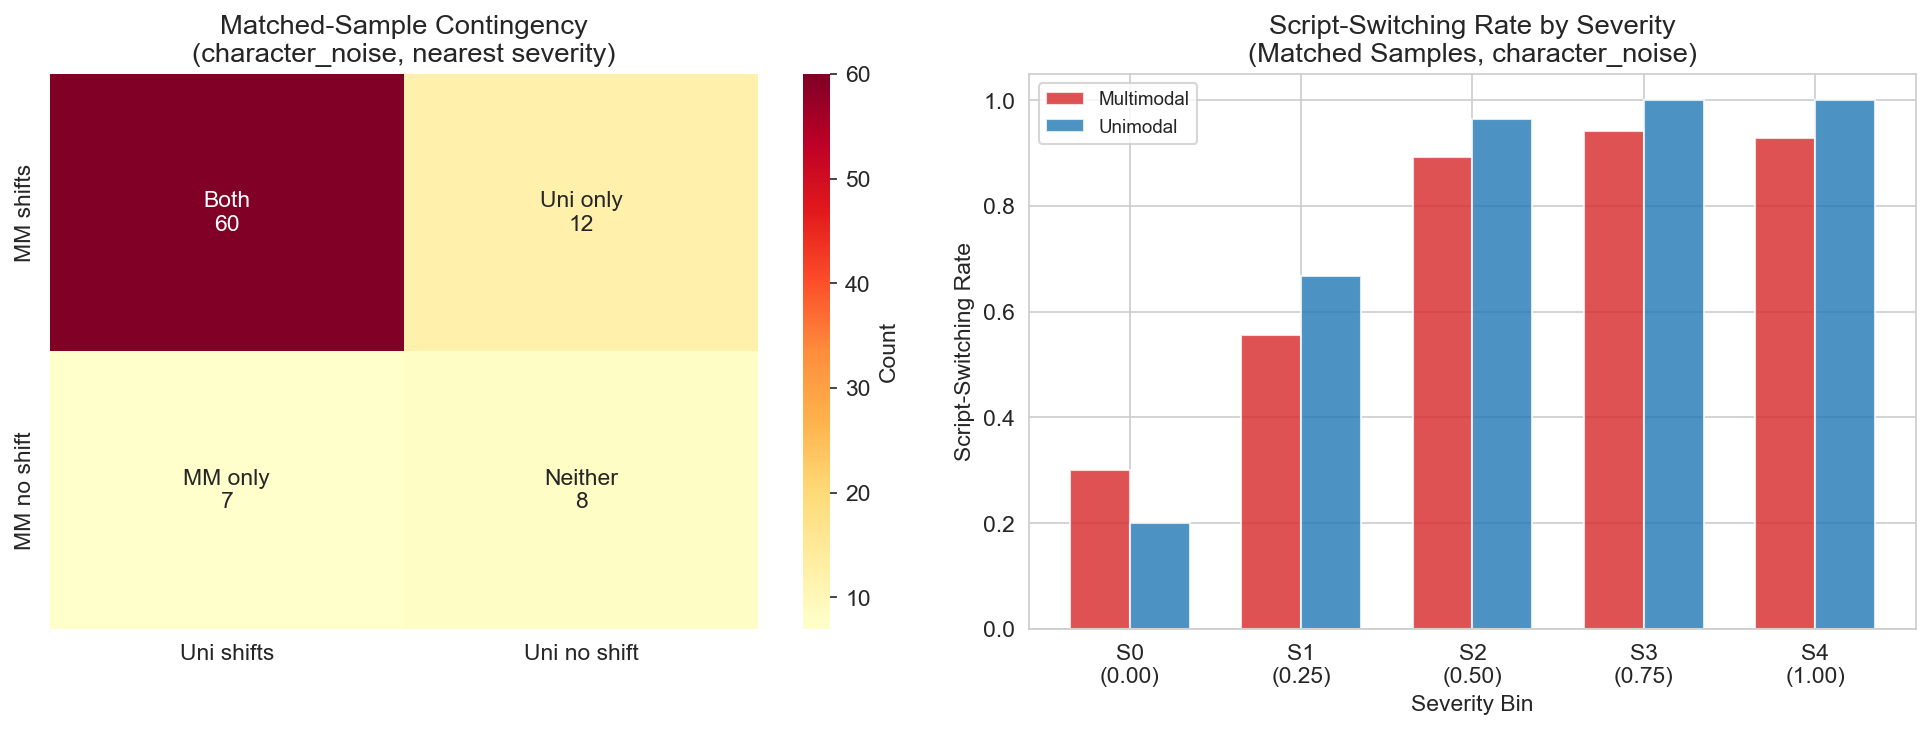

In [69]:
# =======================================================================

if len(df_matched) > 0 and len(df_matched) > 10:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: 2x2 contingency heatmap
    ax = axes[0]
    contingency = np.array([[both, uni_only], [mm_only, neither]])
    labels = np.array([
        [f'Both\n{both}', f'Uni only\n{uni_only}'],
        [f'MM only\n{mm_only}', f'Neither\n{neither}']
    ])
    sns.heatmap(contingency, annot=labels, fmt='', cmap='YlOrRd',
                xticklabels=['Uni shifts', 'Uni no shift'],
                yticklabels=['MM shifts', 'MM no shift'],
                ax=ax, cbar_kws={'label': 'Count'})
    ax.set_title('Matched-Sample Contingency\n(character_noise, nearest severity)')

    # Right: severity-binned comparison
    ax = axes[1]
    bins_mm = df_matched.groupby('sev_bin')['mm_shift'].mean()
    bins_uni = df_matched.groupby('sev_bin')['uni_shift'].mean()
    x = np.array(bins_mm.index)
    width = 0.35
    ax.bar(x - width/2, bins_mm.values, width, label='Multimodal', color='#d62728', alpha=0.8)
    ax.bar(x + width/2, bins_uni.reindex(x, fill_value=0).values, width,
           label='Unimodal', color='#1f77b4', alpha=0.8)
    ax.set_xlabel('Severity Bin')
    ax.set_ylabel('Script-Switching Rate')
    ax.set_xticks(range(5))
    ax.set_xticklabels([f'S{i}\n({SCALE_MAP_INV[i]:.2f})' for i in range(5)])
    ax.set_title('Script-Switching Rate by Severity\n(Matched Samples, character_noise)')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'fig_script_switch_comparison.pdf'))
    plt.show()


In [70]:
# =======================================================================

print('=' * 80)
print('  IMPACT ON REPORTED RESULTS -- IoU=0 DECOMPOSITION')
print('  (Variant A, SWAD*-optimal solutions)')
print('=' * 80)

# For each sample with IoU_M = 0 under SWAD*, classify WHY
zero_samples = df_samples[df_samples.swad_iou_m == 0].copy()
print(f'\nTotal samples with IoU_M = 0: {len(zero_samples)}')

# Classify each zero-IoU sample
decomp_rows = []
for _, row in zero_samples.iterrows():
    sid = int(row['sample_id'])
    st  = row['scene_type']

    # Get SWAD* predictions for this sample
    sp = swad_preds[
        (swad_preds.sample_id == sid) & (swad_preds.scene_type == st)
    ]

    has_script_shift = sp.script_class.isin(
        ['cyrillic_full', 'cyrillic_mixed', 'diacritical']).any()
    has_any_pred = len(sp) > 0
    has_bbox_valid = (sp.bbox_only_iou > 0.5).any() if len(sp) > 0 else False

    # Determine reason for IoU=0
    if not has_any_pred:
        reason = 'no_predictions'
    elif has_script_shift and has_bbox_valid:
        reason = 'script_shift_bbox_valid'
    elif has_script_shift and not has_bbox_valid:
        reason = 'script_shift_bbox_invalid'
    elif (not sp.label_accepted.any()) and len(sp) > 0:
        reason = 'label_mismatch_latin'
    else:
        reason = 'other'

    decomp_rows.append({
        'sample_id': sid,
        'scene_type': st,
        'txt_attack': row['swad_txt_attack'],
        'reason': reason,
        'n_preds': len(sp),
        'max_bbox_iou': sp.bbox_only_iou.max() if len(sp) > 0 else 0.0,
    })

df_decomp = pd.DataFrame(decomp_rows)

print(f'\n  {"Failure Reason":<40} {"Count":>6} {"Pct":>8}')
print(f'  {"-"*56}')
for reason in ['script_shift_bbox_valid', 'script_shift_bbox_invalid',
                'label_mismatch_latin', 'no_predictions', 'other']:
    n = (df_decomp.reason == reason).sum()
    pct = 100 * n / len(df_decomp) if len(df_decomp) > 0 else 0
    nice = {
        'script_shift_bbox_valid':   'Script-shifted, bbox IoU > 0.5 (artifact)',
        'script_shift_bbox_invalid': 'Script-shifted, bbox IoU ≤ 0.5',
        'label_mismatch_latin':      'Latin label, but no match',
        'no_predictions':            'No parseable predictions',
        'other':                     'Other',
    }
    print(f'  {nice.get(reason, reason):<40} {n:>6} {pct:>7.1f}%')

# By text attack
print(f'\n  IoU=0 breakdown by text attack:')
print(f'  {"Attack":<20} {"ScriptShift+BBox":>17} {"Other Zero":>12} {"Total":>8}')
print(f'  {"-"*60}')
for atk in TEXT_ATTACKS:
    sub = df_decomp[df_decomp.txt_attack == atk]
    n_artifact = (sub.reason == 'script_shift_bbox_valid').sum()
    n_other = len(sub) - n_artifact
    print(f'  {TXT_NICE.get(atk, atk):<20} {n_artifact:>17} {n_other:>12} {len(sub):>8}')


  IMPACT ON REPORTED RESULTS -- IoU=0 DECOMPOSITION
  (Variant A, SWAD*-optimal solutions)

Total samples with IoU_M = 0: 349

  Failure Reason                            Count      Pct
  --------------------------------------------------------
  Script-shifted, bbox IoU > 0.5 (artifact)     50    14.3%
  Script-shifted, bbox IoU ≤ 0.5                3     0.9%
  Latin label, but no match                   100    28.7%
  No parseable predictions                    153    43.8%
  Other                                        43    12.3%

  IoU=0 breakdown by text attack:
  Attack                ScriptShift+BBox   Other Zero    Total
  ------------------------------------------------------------
  Homophone                            0          167      167
  Synonym                              0           23       23
  Fragmentation                        0            0        0
  Character Noise                     50           16       66
  Lexical Saliency                     0      